# Data Gen 6: Sigmoid vs No-Class (4x Preview)

First step for the simulation strategy:
- load full simulation settings
- make sigmoid dependencies transparent
- simulate 4 instances (`:sigmoid` + `:no_class`)
- build a 2x4 plot grid with one colorbar per image

Note: this notebook **does not export** anything.


In [1]:
using InteractiveUtils
versioninfo()


Julia Version 1.12.3
Commit 966d0af0fdf (2025-12-15 11:20 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 16 × AMD Ryzen 7 7800X3D 8-Core Processor
  WORD_SIZE: 64
  LLVM: libLLVM-18.1.7 (ORCJIT, znver4)
  GC: Built with stock GC
Threads: 16 default, 1 interactive, 16 GC (on 16 virtual cores)
Environment:
  JULIA_NUM_THREADS = 16


In [2]:
import Pkg
# Resolve the data_generation notebook directory and use absolute include paths.
data_gen_dir = if isfile(joinpath(pwd(), "erpgen.jl"))
    pwd()
else
    candidate = joinpath(pwd(), "notebooks", "data_generation")
    @assert isfile(joinpath(candidate, "erpgen.jl")) "Could not locate notebooks/data_generation/erpgen.jl from current working directory."
    candidate
end
cd(data_gen_dir)
Pkg.activate(data_gen_dir)
Pkg.instantiate()
using Random
using Distributions: Normal, Uniform
using Interpolations
using CairoMakie
using UnfoldSim: PinkNoise, WhiteNoise, RedNoise, ExponentialNoise
include(joinpath(data_gen_dir, "erpgen.jl"))
using .ERPGen
using .ERPGen: DEFAULT_NOISE_POOL
include(joinpath(data_gen_dir, "..", "utils", "erp_image_utils.jl"))
using .ERPImageUtils: clipped_color_stats_quantile_zero_ticks
ERPGen.verify_unfoldsim_version!()


  Activating project at `~/Dokumente/BA2/notebooks/data_generation`
    Updating registry at `~/.julia/registries/General.toml`


UnfoldSim version 0.5.0 verified.


Config loaded. n_instances=4, raw=513x2508, target=64x64, q=(0.01, 0.99).
=== Sigmoid dependency report ===
Requested output patterns in this run: [:sigmoid]
Loaded component patterns in this run: [:sigmoid, :one_sided_fan, :two_sided_fan, :diverging_bar, :hourglass, :tilted_bar]
Sigmoid sorting key in ERPGen: zip(Δlatency, latency) (fixed in erpgen/components.jl).
Always active waveform components: P1 + N170 + P3 + sampled noise.
Extra time-varying components active in the latent ERP: [:one_sided_fan, :two_sided_fan, :tilted_bar]
N170 covariate terms active: baseline + diverging_bar + hourglass.
no_class image source: same cropped trials, random trial-order permutation before image build.
Simulated instances: 4
  Run 1 | sampling_rate=512Hz | epoch=1.0s | raw_size=(513, 2508) | fixed_size=(513, 2508)
  Run 2 | sampling_rate=512Hz | epoch=1.0s | raw_size=(513, 2508) | fixed_size=(513, 2508)
  Run 3 | sampling_rate=512Hz | epoch=1.0s | raw_size=(513, 2508) | fixed_size=(513, 2508)
  Run

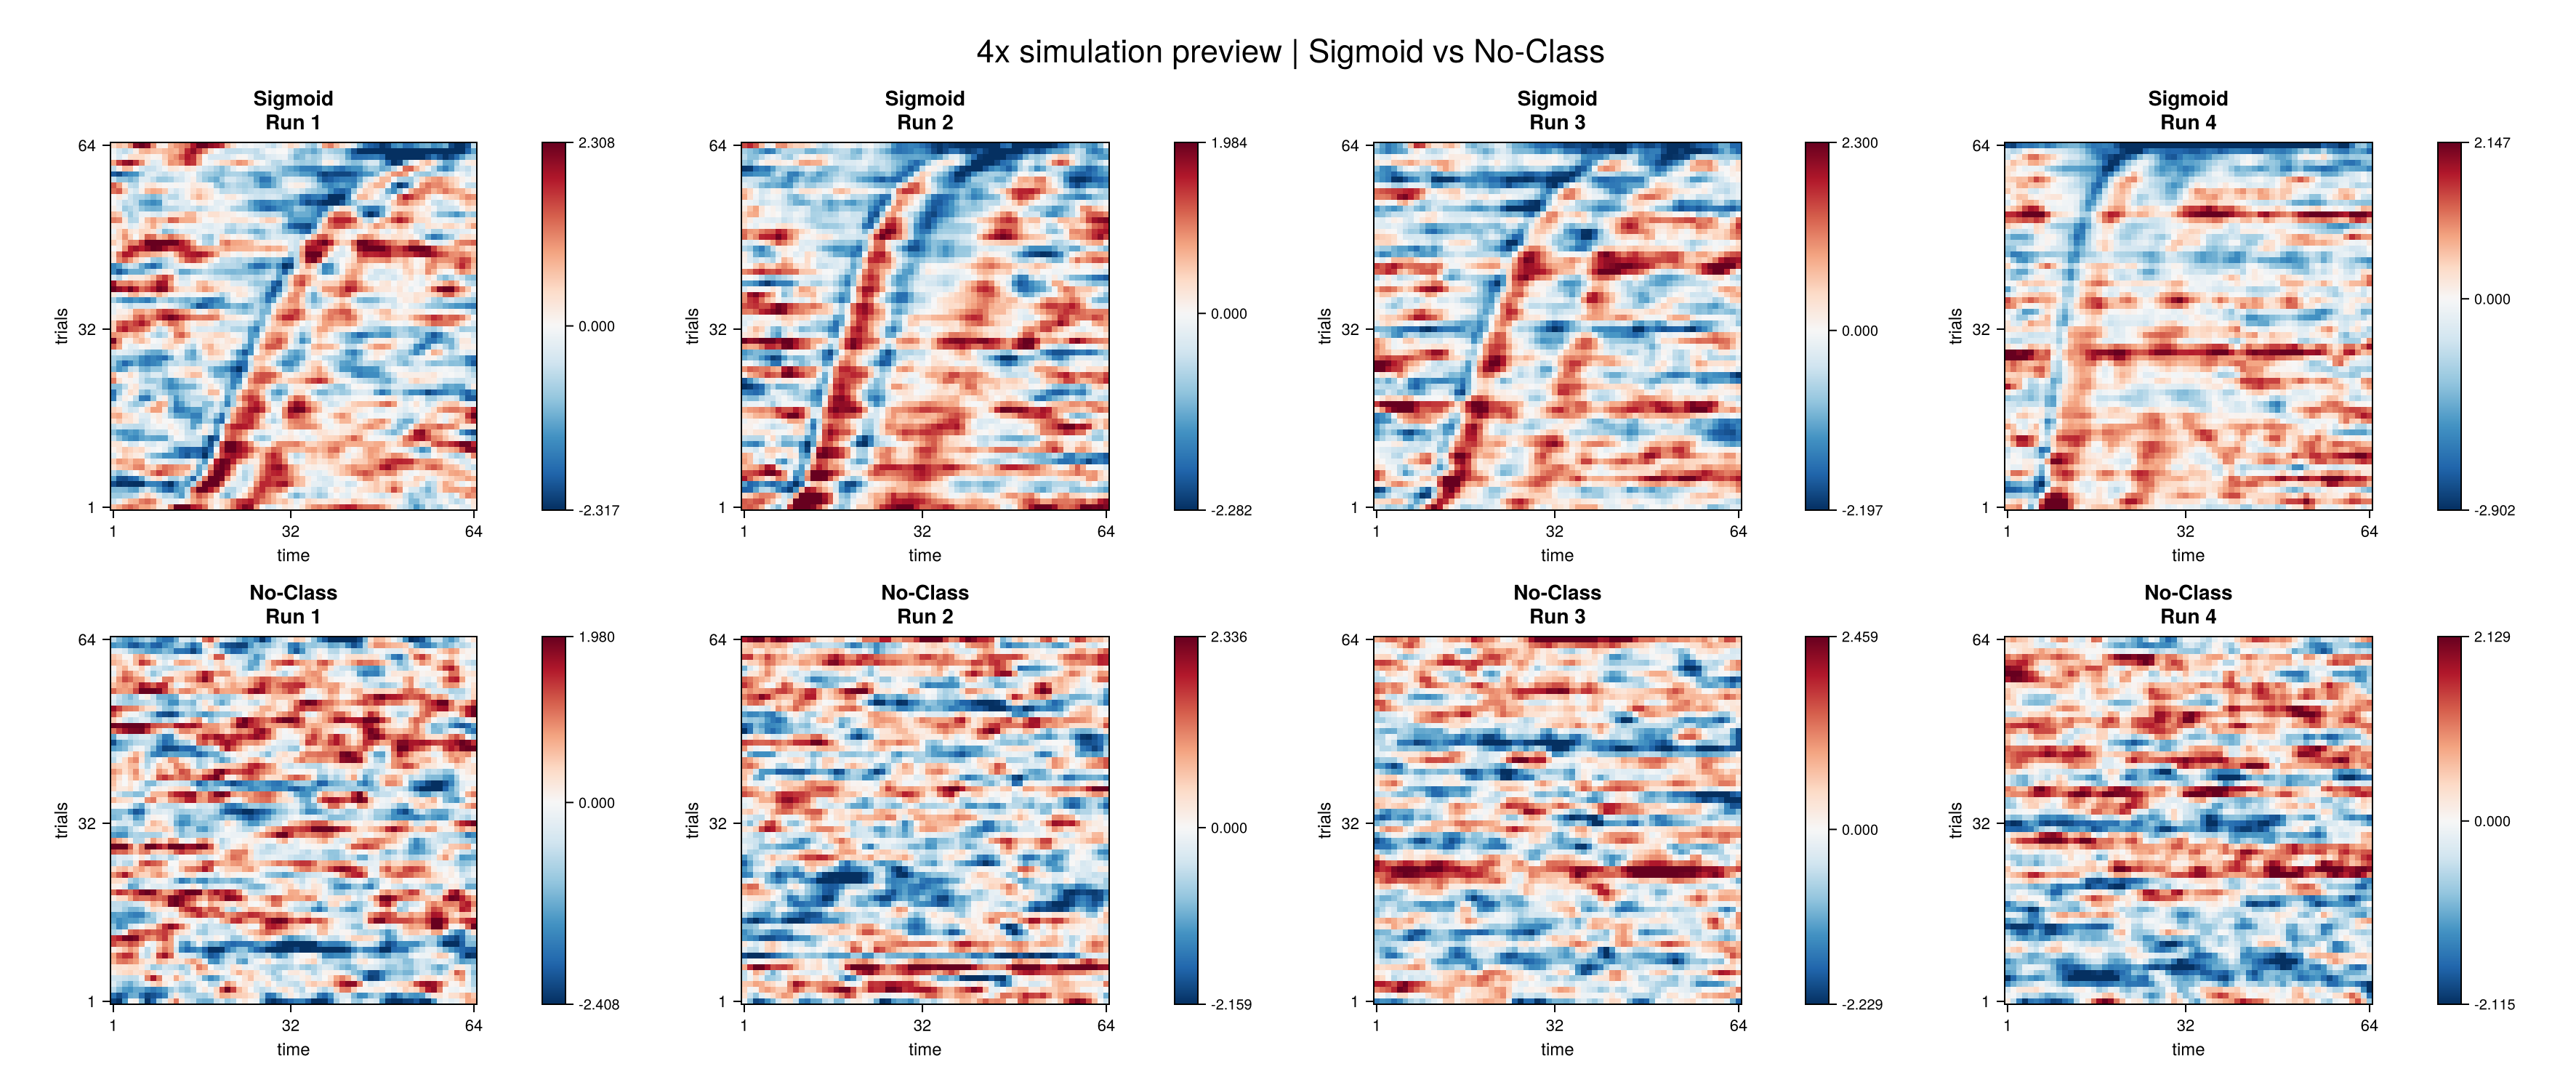

In [4]:
# ============================================================================
# One-cell workflow: parameter settings + simulation + plot
# Edit only this cell for quick iteration, then run it to preview output.
# ============================================================================
# ============================================================================
# Global settings (first preview run, no export)
# ============================================================================
# Standalone guard: this cell can be run directly after kernel restart.
if !isdefined(Main, :ERPGen)
    include("erpgen.jl")
end
using .ERPGen
if !isdefined(Main, :ERPImageUtils)
    include(joinpath(pwd(), "..", "utils", "erp_image_utils.jl"))
end
using .ERPImageUtils: clipped_color_stats_quantile_zero_ticks
import Random
import Distributions
using Distributions: Distribution
using CairoMakie
base_seed = Int(mod(time_ns(), typemax(Int)))
Random.seed!(base_seed)
n_instances = 4
q_low = 0.01
q_high = 0.99
real_n_trials = 2508
real_n_timepoints = 513
real_sampling_rate = 512
real_epoch_duration_s = (real_n_timepoints - 1) / real_sampling_rate
struct FixedDist <: Distribution{Distributions.Univariate, Distributions.Continuous}
    value::Float64
end
Random.rand(rng::Random.AbstractRNG, d::FixedDist) = d.value
Random.rand(d::FixedDist) = d.value
Distributions.mean(d::FixedDist) = d.value
Distributions.std(::FixedDist) = 0.0
fixed_dist(target::Real) = FixedDist(Float64(target))
# Keep only :sigmoid as the output/sort target. The simulator still loads all
# component families so the latent ERP stays rich; :no_class is derived later
# by random sorting of the same simulated trials.
patterns = [:sigmoid]
base_config = ERPGen.GenerationConfig()
target_height = base_config.processing.target_height
target_width = base_config.processing.target_width
sim_config = ERPGen.SimulationConfig(
    mu_dist = Distributions.Normal(4.5, 0.3),
    sigma_dist = base_config.sim.sigma_dist,
    epoch_duration_dist = fixed_dist(real_epoch_duration_s),
    sampling_rate_dist = fixed_dist(real_sampling_rate),
    n_trials_dist = fixed_dist(real_n_trials),
)
component_config = base_config.components
pattern_config = ERPGen.PatternConfig(
    patterns = patterns,
    loaded_patterns = ERPGen.DEFAULT_PATTERN_LIST,
    covariate_dists = base_config.patterns.covariate_dists,
    diverging_bar_levels = base_config.patterns.diverging_bar_levels,
)
noise_config = base_config.noise
processing_config = ERPGen.ProcessingConfig(
    dropout_trials_rate_dist = fixed_dist(0.0),
    crop_start_dist = fixed_dist(0.0),
    crop_end_dist = fixed_dist(0.0),
    zscore_timepoints = true,
    resize_antialias = true,
    low_pass_factor = base_config.processing.low_pass_factor,
    resize_method = base_config.processing.resize_method,
    target_height = target_height,
    target_width = target_width,
)
runtime_config = ERPGen.RuntimeConfig(
    threaded = false,
    show_progress = false,
    blas_threads = 1,
    progress_every = 10,
)
config = ERPGen.GenerationConfig(
    sim = sim_config,
    components = component_config,
    patterns = pattern_config,
    noise = noise_config,
    processing = processing_config,
    runtime = runtime_config,
)
println("Config loaded. n_instances=$(n_instances), raw=$(real_n_timepoints)x$(real_n_trials), target=$(target_height)x$(target_width), q=($(q_low), $(q_high)).")
function print_sigmoid_dependency_report(config::ERPGen.GenerationConfig)
    pset = Set(config.patterns.patterns)
    lset = Set(config.patterns.loaded_patterns)
    extra_components = Symbol[]
    :one_sided_fan in lset && push!(extra_components, :one_sided_fan)
    :two_sided_fan in lset && push!(extra_components, :two_sided_fan)
    :tilted_bar in lset && push!(extra_components, :tilted_bar)
    has_diverging = :diverging_bar in lset
    has_hourglass = :hourglass in lset
    println("=== Sigmoid dependency report ===")
    println("Requested output patterns in this run: ", collect(config.patterns.patterns))
    println("Loaded component patterns in this run: ", collect(config.patterns.loaded_patterns))
    println("Sigmoid sorting key in ERPGen: zip(Δlatency, latency) (fixed in erpgen/components.jl).")
    println("Always active waveform components: P1 + N170 + P3 + sampled noise.")
    println("Extra time-varying components active in the latent ERP: ", extra_components)
    if has_diverging && has_hourglass
        println("N170 covariate terms active: baseline + diverging_bar + hourglass.")
    elseif has_diverging
        println("N170 covariate terms active: baseline + diverging_bar.")
    elseif has_hourglass
        println("N170 covariate terms active: baseline + hourglass.")
    else
        println("N170 covariate terms active: baseline only.")
    end
    println("no_class image source: same cropped trials, random trial-order permutation before image build.")
end
print_sigmoid_dependency_report(config)
function simulate_sigmoid_no_class_instance(config::ERPGen.GenerationConfig, rng::Random.AbstractRNG)
    raw = ERPGen.simulate_raw_erp(config, rng)
    data_fixed = raw.data
    events_fixed = raw.events
    sorted = ERPGen.sort_by_patterns(data_fixed, events_fixed, [:sigmoid, :no_class], rng)
    processed = ERPGen.process_images(sorted, config.processing)
    normalized = ERPGen.apply_zscore(processed.images, config.processing)
    return (
        sigmoid = normalized[:sigmoid],
        no_class = normalized[:no_class],
        raw_params = raw.params,
        raw_size = size(raw.data),
        fixed_size = size(data_fixed),
    )
end
instances = [simulate_sigmoid_no_class_instance(config, Random.Xoshiro(base_seed + 10_000 * i)) for i in 1:n_instances]
sigmoid_images = [inst.sigmoid for inst in instances]
no_class_images = [inst.no_class for inst in instances]
println("Simulated instances: ", length(instances))
for (i, inst) in enumerate(instances)
    println(
        "  Run ", i,
        " | sampling_rate=", inst.raw_params.sampling_rate,
        "Hz | epoch=", round(inst.raw_params.epoch_duration_s; digits = 3),
        "s | raw_size=", inst.raw_size,
        " | fixed_size=", inst.fixed_size,
    )
end
function axis_ticks(n::Int)
    mid = Int(cld(n, 2))
    vals = [1, mid, n]
    return vals, string.(vals)
end
function plot_sigmoid_vs_noclass(sigmoid_imgs::Vector{<:AbstractMatrix}, no_class_imgs::Vector{<:AbstractMatrix};
    q_low::Float64 = 0.01,
    q_high::Float64 = 0.99)
    n = min(length(sigmoid_imgs), length(no_class_imgs))
    n == 0 && error("No images to plot.")
    fig = Figure(size = (350 * n, 750), figure_padding = 22)
    Label(fig[0, 1:(2 * n)],
        "4x simulation preview | Sigmoid vs No-Class";
        fontsize = 22,
        tellwidth = false)
    rows = [
        (name = "Sigmoid", imgs = sigmoid_imgs),
        (name = "No-Class", imgs = no_class_imgs),
    ]
    for (row_i, row) in enumerate(rows)
        for run_i in 1:n
            img = Float32.(row.imgs[run_i])
            clipped, crange, tick_vals, tick_labels, cmap =
                clipped_color_stats_quantile_zero_ticks(img; q_low = q_low, q_high = q_high)
            xtick_vals, xtick_labels = axis_ticks(size(img, 2))
            ytick_vals, ytick_labels = axis_ticks(size(img, 1))
            img_col = 2 * run_i - 1
            cb_col = 2 * run_i
            ax = Axis(fig[row_i, img_col];
                title = "$(row.name)\nRun $(run_i)",
                titlesize = 14,
                titlegap = 6,
                aspect = DataAspect(),
                xticks = (xtick_vals, xtick_labels),
                yticks = (ytick_vals, ytick_labels),
                xticklabelsize = 11,
                yticklabelsize = 11,
                xlabel = "time",
                ylabel = "trials",
                xlabelsize = 12,
                ylabelsize = 12,
            )
            hm = heatmap!(ax, permutedims(clipped, (2, 1));
                colormap = cmap,
                colorrange = crange)
            Colorbar(fig[row_i, cb_col], hm;
                width = 16,
                ticklabelsize = 10,
                ticks = (tick_vals, tick_labels))
            colsize!(fig.layout, img_col, Fixed(280))
            colsize!(fig.layout, cb_col, Fixed(58))
        end
    end
    rowgap!(fig.layout, 12)
    colgap!(fig.layout, 10)
    resize_to_layout!(fig)
    return fig
end
fig_preview = plot_sigmoid_vs_noclass(sigmoid_images, no_class_images; q_low = q_low, q_high = q_high)
fig_preview


## Synthetic-to-Real Pipeline (automatic, no export)

These additional cells implement multiple simulation approaches, train three models (`ResNet18` pretrained 1ch, `ResNet18` untrained 1ch, `3-layer CNN`) on simulated data, and validate on manually labeled real ERP images.

Implemented approaches:
1. `broad_random`: classic broad domain randomization.
2. `lhs_calibrated`: space-filling candidate search via Latin Hypercube Sampling (LHS) + automatic calibration to real sigmoid shape features.
3. `two_zone_mixture`: mixture of realistic, edge, and stress zones (70/20/10) to increase shape diversity.
4. `mc_random_search`: pure Monte Carlo random-search calibration (uniform sampling) as a comparison to LHS.

Key references (for comments/methodology in code):
- Domain Randomization: Tobin et al. 2017: https://arxiv.org/abs/1703.06907
- Offline DR / distribution adaptation: DROPO 2023: https://www.sciencedirect.com/science/article/pii/S0921889023000714
- LHS (classic): McKay et al. 1979 (Technometrics): https://doi.org/10.1080/00401706.1979.10489755
- Random Search: Bergstra & Bengio 2012 (JMLR): https://jmlr.org/papers/v13/bergstra12a.html
- MMD as distribution distance: Gretton et al. 2012: https://www.jmlr.org/beta/papers/v13/gretton12a.html
- ResNet original: He et al. 2016: https://www.cv-foundation.org/openaccess/content_cvpr_2016/html/He_Deep_Residual_Learning_CVPR_2016_paper.html
- Metalhead ResNet + pretrain usage: https://fluxml.ai/Metalhead.jl/stable/howto/resnet/
- EEG/ERP simulation reference: SEREEGA (Krol et al. 2018): https://www.frontiersin.org/articles/10.3389/fninf.2018.00089/full
- Real ERP morphology reference: ERP CORE (Kappenman et al. 2021): https://doi.org/10.1111/psyp.13772


In [4]:
# ============================================================================
# Setup for synthetic-to-real experiments
# ============================================================================
# We reuse model packages from notebooks/model_test environment without changing
# the data_generation Project.toml.
const MODEL_TEST_ENV = abspath(joinpath(pwd(), "..", "model_test"))
if !(MODEL_TEST_ENV in LOAD_PATH)
    push!(LOAD_PATH, MODEL_TEST_ENV)
end
using CSV, DataFrames, HDF5, Random, Statistics, Printf
using Distributions: Normal, Uniform, Dirac, Distribution
using StatsBase: quantile
using ImageFiltering: imfilter
using Images: imresize
using Flux
using Flux: onehotbatch, onecold
using CUDA
using cuDNN
using MLUtils: DataLoader
using StatisticalMeasures
using StatisticalMeasures: macro_avg
using Metalhead
if !isdefined(Main, :ERPGen)
    include("erpgen.jl")
end
using .ERPGen
if !isdefined(Main, :ERPImageUtils)
    include(joinpath(pwd(), "..", "utils", "erp_image_utils.jl"))
end
using .ERPImageUtils: gaussian_kernel
@assert CUDA.functional(true) "CUDA is not functional. NVIDIA GPU training cannot run."
CUDA.allowscalar(false)
CUDA.device!(0)
println("CUDA device: ", CUDA.name(CUDA.device()))


CUDA device: NVIDIA GeForce RTX 4070


In [5]:
# ============================================================================
# Real data + labels loading (same strategy as semi_supervised_learing.ipynb)
# ============================================================================
const S2R_RESULTS_CSV_PATHS = [
    joinpath(pwd(), "..", "model_test", "results", "project-14-at-2026-02-15-23-09-f5225e5c.csv"),
    joinpath(pwd(), "..", "model_test", "results", "project-15-at-2026-02-18-19-35-828515fe.csv"),
]
const S2R_H5_PATH = joinpath(pwd(), "..", "model_test", "data_fixations.hdf5")
const S2R_EVENTS_CSV_PATH = joinpath(pwd(), "..", "model_test", "events.csv")
for p in vcat(S2R_RESULTS_CSV_PATHS, [S2R_H5_PATH, S2R_EVENTS_CSV_PATH])
    @assert isfile(p) "File not found: $p"
end
function s2r_load_erps_from_h5(path::AbstractString)
    return h5open(path, "r") do f
        candidates = ["erps", "/erps", "data", "/data/data_fixations.hdf5", "data/data_fixations.hdf5"]
        for key in candidates
            if haskey(f, key)
                obj = f[key]
                if obj isa HDF5.Dataset
                    return read(obj)
                end
            end
        end
        function first_dataset(g)
            for k in keys(g)
                obj = g[k]
                if obj isa HDF5.Dataset
                    return read(obj)
                elseif obj isa HDF5.Group
                    x = first_dataset(obj)
                    x === nothing || return x
                end
            end
            return nothing
        end
        x = first_dataset(f)
        x === nothing && error("No dataset found in HDF5 file: $path")
        return x
    end
end
function s2r_load_and_merge_label_sources(paths::Vector{String})
    dfs = DataFrame[]
    for p in paths
        df = CSV.read(p, DataFrame)
        df.source_csv = fill(basename(p), nrow(df))
        push!(dfs, df)
    end
    labels_all = vcat(dfs...; cols = :union)
    if :image in names(labels_all)
        updated_at_str = :updated_at in names(labels_all) ? string.(coalesce.(labels_all.updated_at, "")) : fill("", nrow(labels_all))
        created_at_str = :created_at in names(labels_all) ? string.(coalesce.(labels_all.created_at, "")) : fill("", nrow(labels_all))
        labels_all.updated_at_str = updated_at_str
        labels_all.created_at_str = created_at_str
        # Keep latest annotation per image.
        sort!(labels_all, [:image, :updated_at_str, :created_at_str], rev = [false, true, true])
        labels_merged = unique(labels_all, :image)
    else
        labels_merged = labels_all
    end
    return labels_all, labels_merged
end
s2r_parse_class_id(v) = begin
    t = tryparse(Int, strip(string(v)))
    t === nothing ? missing : t
end
function s2r_has_required_metadata(row)
    cols = propertynames(row)
    if !(:channel in cols && :sort_variable in cols)
        return false
    end
    return !ismissing(row.channel) && !ismissing(row.sort_variable)
end
const S2R_SAMPLING_RATE = 512
const S2R_PRE_STIM_S = 0.5
const S2R_TIME_ZERO_IDX = Int(round(S2R_PRE_STIM_S * S2R_SAMPLING_RATE)) + 1
# Keep preprocessing fixed to semi_supervised_learing.ipynb defaults.
const S2R_TARGET_SIZE = (64, 64)
const S2R_LOWPASS_SIGMA = 75.0f0
const S2R_LOWPASS_KERNEL_SIZE = (21, 21)
const S2R_FILTER_BORDER = "reflect"
const S2R_ZSCORE_TIMEPOINTS = true
function s2r_sortvalues_from(df::DataFrame, col::Symbol)
    v = df[!, col]
    if eltype(v) <: Number
        return Float64.(v)
    end
    return collect(v)
end
function s2r_extract_channel_trials(erps, events::DataFrame, channel::Int; time_zero_idx::Int = S2R_TIME_ZERO_IDX)
    @assert 1 <= channel <= size(erps, 1) "channel out of range"
    data = Float32.(erps[channel, time_zero_idx:end, :])
    n = min(size(data, 2), nrow(events))
    return data[:, 1:n], events[1:n, :]
end
function s2r_preprocess_real_image(data_time_trials::AbstractMatrix, events_trials::DataFrame, sort_col::Symbol)
    @assert size(data_time_trials, 2) == nrow(events_trials) "trial count mismatch between matrix and events"
    @assert sort_col in propertynames(events_trials) "sort column not found: $(sort_col)"
    sortvals = s2r_sortvalues_from(events_trials, sort_col)
    order = sortperm(sortvals)
    data_sorted = data_time_trials[:, order]              # (time, trial)
    @assert S2R_ZSCORE_TIMEPOINTS "zscore must stay enabled for this pipeline."
    # Use existing preprocessing helpers from ERPImageUtils (same as semi_supervised).
    data_z = ERPImageUtils.zscore_timepoints(data_sorted)
    img_trials_time = Float32.(permutedims(data_z, (2, 1)))  # (trial, time)
    # Orientation guard for CNN input convention in this notebook:
    # x-axis = time, y-axis = stacked trials.
    @assert size(img_trials_time, 1) == size(data_sorted, 2)
    @assert size(img_trials_time, 2) == size(data_sorted, 1)
    kernel = ERPImageUtils.gaussian_kernel(S2R_LOWPASS_SIGMA, size(img_trials_time), S2R_TARGET_SIZE, S2R_LOWPASS_KERNEL_SIZE)
    img_lowpass = Float32.(imfilter(img_trials_time, kernel, S2R_FILTER_BORDER))
    img_resized = Float32.(imresize(img_lowpass, S2R_TARGET_SIZE))
    return img_resized, size(img_trials_time)
end
function s2r_build_real_eval_dataset(erps, events::DataFrame, labels_df::DataFrame;
    sigmoid_class_id::Int = 1,
    no_class_id::Int = 0)
    rows = NamedTuple[]
    imgs = Matrix{Float32}[]
    keep_ids = Set([sigmoid_class_id, no_class_id])
    for row in eachrow(labels_df)
        class_id = Int(row.erp_class_id)
        class_id in keep_ids || continue
        channel = Int(row.channel_int)
        sort_col = row.sort_var_symbol
        data_full, events_full = s2r_extract_channel_trials(erps, events, channel)
        img, raw_shape = Base.invokelatest(s2r_preprocess_real_image, data_full, events_full, sort_col)
        binary = Int(class_id == sigmoid_class_id)
        push!(rows, (
            channel = channel,
            sort_var = String(sort_col),
            class_id = class_id,
            binary_label = binary,
            raw_trials_time_shape = raw_shape,
            image_id = hasproperty(row, :image_file) && !ismissing(row.image_file) ? String(row.image_file) : "unknown_image",
        ))
        push!(imgs, img)
    end
    out_df = DataFrame(rows)
    out_df.processed_img = imgs
    return out_df
end
# Load real tensors + labels
s2r_erps = s2r_load_erps_from_h5(S2R_H5_PATH)
s2r_events = CSV.read(S2R_EVENTS_CSV_PATH, DataFrame)
s2r_labels_all_df, s2r_labels_merged_df = s2r_load_and_merge_label_sources(S2R_RESULTS_CSV_PATHS)
s2r_labels_merged_df.erp_class_id = [s2r_parse_class_id(v) for v in s2r_labels_merged_df.erp_class]
valid_mask = map(v -> !ismissing(v), s2r_labels_merged_df.erp_class_id)
meta_mask = map(s2r_has_required_metadata, eachrow(s2r_labels_merged_df))
s2r_labels_df = copy(s2r_labels_merged_df[valid_mask .& meta_mask, :])
s2r_labels_df.channel_int = Int.(s2r_labels_df.channel)
s2r_labels_df.sort_var_symbol = Symbol.(String.(s2r_labels_df.sort_variable))
s2r_labels_df.binary_label = Int.(s2r_labels_df.erp_class_id .> 0)
s2r_real_eval_df = Base.invokelatest(s2r_build_real_eval_dataset, s2r_erps, s2r_events, s2r_labels_df; sigmoid_class_id = 1, no_class_id = 0)
s2r_real_sigmoid_df = copy(s2r_real_eval_df[s2r_real_eval_df.binary_label .== 1, :])
println("ERP tensor size: ", size(s2r_erps), " (channel, time, trial)")
println("Events rows: ", nrow(s2r_events))
println("Labels imported (all): ", nrow(s2r_labels_all_df))
println("Labels merged unique by image: ", nrow(s2r_labels_merged_df))
println("Labels with valid metadata: ", nrow(s2r_labels_df))
println("Real eval rows kept for this task (class_id in {0,1}): ", nrow(s2r_real_eval_df))
println("Real sigmoid rows for calibration (class_id=1): ", nrow(s2r_real_sigmoid_df))
@assert nrow(s2r_real_sigmoid_df) > 0 "No real sigmoid labels found (expected class_id=1)."
@assert all(size.(s2r_real_eval_df.processed_img) .== Ref(S2R_TARGET_SIZE))
# Quick orientation evidence from real pipeline before resize.
println("Example raw (trial,time) shape before resize from real eval rows: ",
    [s2r_real_eval_df.raw_trials_time_shape[i] for i in 1:min(5, nrow(s2r_real_eval_df))])


ERP tensor size: (128, 769, 2508) (channel, time, trial)
Events rows: 2508
Labels imported (all): 500
Labels merged unique by image: 500
Labels with valid metadata: 500
Real eval rows kept for this task (class_id in {0,1}): 488
Real sigmoid rows for calibration (class_id=1): 36
Example raw (trial,time) shape before resize from real eval rows: [(2508, 513), (2508, 513), (2508, 513), (2508, 513), (2508, 513)]


In [6]:
# ============================================================================
# Shape features, MMD distance and Latin Hypercube utilities
# ============================================================================
# Feature extractor for sigmoid morphology in ERP images.
# Input convention is fixed: matrix is (trial, time) => y=trial, x=time.
# Extended feature set (13 dims) to better separate LHS/MC candidates.
function s2r_sigmoid_shape_features(img::AbstractMatrix{<:Real})
    x = Float32.(img)
    h, w = size(x)
    # --- Global first/second-order features (3) ---
    gx = diff(x; dims = 2)  # time-direction gradients
    gy = diff(x; dims = 1)  # trial-direction gradients
    feat_global_std = std(x)
    feat_mean_gx = mean(abs.(gx))
    feat_mean_gy = mean(abs.(gy))
    # --- Local patch statistics (3) ---
    patch_size = 8
    patch_stds = Float32[]
    if h >= patch_size && w >= patch_size
        for i in 1:patch_size:(h - patch_size + 1)
            for j in 1:patch_size:(w - patch_size + 1)
                push!(patch_stds, std(@view x[i:(i + patch_size - 1), j:(j + patch_size - 1)]))
            end
        end
    end
    isempty(patch_stds) && push!(patch_stds, std(x))
    feat_patch_std_mean = mean(patch_stds)
    feat_patch_std_std = std(patch_stds)
    feat_patch_std_skew = if length(patch_stds) > 2
        z = (patch_stds .- feat_patch_std_mean) ./ max(feat_patch_std_std, 1f-6)
        mean(z .^ 3)
    else
        0f0
    end
    # --- Temporal autocorrelation (1) ---
    autocorrs = Float32[]
    for i in 1:h
        row = @view x[i, :]
        if length(row) > 1
            c = cor(row[1:(end - 1)], row[2:end])
            isfinite(c) && push!(autocorrs, Float32(c))
        end
    end
    feat_autocorr_mean = isempty(autocorrs) ? 0f0 : mean(autocorrs)
    # --- Trial-gradient concentration (2) ---
    trial_grad_profile = vec(mean(abs.(gy); dims = 1))
    if length(trial_grad_profile) > 1
        feat_grad_concentration = maximum(trial_grad_profile) / (mean(trial_grad_profile) + 1f-6)
        feat_grad_peak_pos = Float32(argmax(trial_grad_profile)) / Float32(length(trial_grad_profile))
    else
        feat_grad_concentration = 1f0
        feat_grad_peak_pos = 0.5f0
    end
    # --- Column-wise IQR profile (2) ---
    q25_cols = Float32[quantile(vec(@view x[:, j]), 0.25f0) for j in 1:w]
    q75_cols = Float32[quantile(vec(@view x[:, j]), 0.75f0) for j in 1:w]
    iqr_profile = q75_cols .- q25_cols
    feat_iqr_std = std(iqr_profile)
    feat_iqr_trend = if length(iqr_profile) > 1
        t = collect(range(1f0, Float32(length(iqr_profile)); length = length(iqr_profile)))
        c = cor(t, iqr_profile)
        isfinite(c) ? Float32(c) : 0f0
    else
        0f0
    end
    # --- Energy distribution over trial/time axes (2) ---
    row_energies = vec(sum(x .^ 2; dims = 2))
    col_energies = vec(sum(x .^ 2; dims = 1))
    feat_row_energy_cv = std(row_energies) / (mean(row_energies) + 1f-6)
    feat_col_energy_cv = std(col_energies) / (mean(col_energies) + 1f-6)
    return Float32[
        feat_global_std,         #  1
        feat_mean_gx,            #  2
        feat_mean_gy,            #  3
        feat_patch_std_mean,     #  4
        feat_patch_std_std,      #  5
        feat_patch_std_skew,     #  6
        feat_autocorr_mean,      #  7
        feat_grad_concentration, #  8
        feat_grad_peak_pos,      #  9
        feat_iqr_std,            # 10
        feat_iqr_trend,          # 11
        feat_row_energy_cv,      # 12
        feat_col_energy_cv,      # 13
    ]
end
function s2r_feature_matrix(imgs::Vector{<:AbstractMatrix})
    @assert !isempty(imgs)
    f0 = s2r_sigmoid_shape_features(imgs[1])
    F = Matrix{Float32}(undef, length(f0), length(imgs))
    F[:, 1] = f0
    for i in 2:length(imgs)
        F[:, i] = s2r_sigmoid_shape_features(imgs[i])
    end
    return F
end
function s2r_feature_summary(F::AbstractMatrix)
    μ = vec(mean(F; dims = 2))
    σ = vec(std(F; dims = 2))
    σ = max.(σ, 1f-5)
    return (μ = μ, σ = σ)
end
# MMD reference:
# Gretton et al. 2012, A Kernel Two-Sample Test
# https://www.jmlr.org/beta/papers/v13/gretton12a.html
function s2r_mmd2_rbf(X::AbstractMatrix, Y::AbstractMatrix; gamma::Union{Nothing, Float64} = nothing)
    # X, Y shape: (features, samples)
    nx = size(X, 2)
    ny = size(Y, 2)
    @assert nx > 1 && ny > 1
    if isnothing(gamma)
        Z = hcat(Float64.(X), Float64.(Y))
        d2 = Float64[]
        n = size(Z, 2)
        for i in 1:(n - 1), j in (i + 1):n
            push!(d2, sum((Z[:, i] .- Z[:, j]).^2))
        end
        med = isempty(d2) ? 1.0 : median(d2)
        gamma = 1.0 / max(med, 1e-6)
    end
    Kxx = 0.0
    Kyy = 0.0
    Kxy = 0.0
    for i in 1:nx, j in 1:nx
        i == j && continue
        Kxx += exp(-gamma * sum((Float64.(X[:, i]) .- Float64.(X[:, j])).^2))
    end
    for i in 1:ny, j in 1:ny
        i == j && continue
        Kyy += exp(-gamma * sum((Float64.(Y[:, i]) .- Float64.(Y[:, j])).^2))
    end
    for i in 1:nx, j in 1:ny
        Kxy += exp(-gamma * sum((Float64.(X[:, i]) .- Float64.(Y[:, j])).^2))
    end
    mmd2 = Kxx / (nx * (nx - 1)) + Kyy / (ny * (ny - 1)) - 2 * Kxy / (nx * ny)
    return Float64(mmd2)
end
# Space-filling design utility (LHS):
# McKay et al. 1979 (Technometrics)
# https://doi.org/10.1080/00401706.1979.10489755
function s2r_latin_hypercube(n::Int, d::Int, rng::AbstractRNG)
    X = Matrix{Float64}(undef, n, d)
    for j in 1:d
        p = randperm(rng, n)
        u = rand(rng, n)
        X[:, j] = (p .- u) ./ n
    end
    return X
end
s2r_real_sigmoid_features = s2r_feature_matrix(s2r_real_sigmoid_df.processed_img)
s2r_real_sigmoid_feature_summary = s2r_feature_summary(s2r_real_sigmoid_features)
println("Real sigmoid feature matrix size: ", size(s2r_real_sigmoid_features), " (features x samples)")
println("Real sigmoid feature mean vector: ", round.(s2r_real_sigmoid_feature_summary.μ; digits = 4))


Real sigmoid feature matrix size: (13, 36) (features x samples)
Real sigmoid feature mean vector: Float32[0.2013, 0.0671, 0.2001, 0.1763, 0.0364, 0.6546, 0.8278, 1.2568, 0.4032, 0.0363, 0.0931, 0.745, 0.1927]


In [7]:
# ============================================================================
# Automatic simulation approaches
# ============================================================================
function s2r_time_seed()
    return Int(mod(time_ns(), typemax(Int)))
end
function s2r_make_base_sigmoid_config(; target_size::Tuple{Int, Int} = S2R_TARGET_SIZE)
    base = ERPGen.GenerationConfig()
    fixed_trials = isdefined(Main, :s2r_events) ? nrow(s2r_events) : 2508
    fixed_trials = max(100, Int(fixed_trials))
    fixed_trials += isodd(fixed_trials) ? 1 : 0
    fixed_sampling_rate = Int(S2R_SAMPLING_RATE)
    fixed_timepoints = 513
    fixed_epoch_duration_s = Float64((fixed_timepoints - 1) / fixed_sampling_rate)
    sim = ERPGen.SimulationConfig(
        mu_dist = Distributions.Normal(4.2, 0.3),
        sigma_dist = base.sim.sigma_dist,
        epoch_duration_dist = Dirac(fixed_epoch_duration_s),
        sampling_rate_dist = Dirac(Float64(fixed_sampling_rate)),
        n_trials_dist = Dirac(Float64(fixed_trials)),
    )
    # Keep ERPGen component defaults as requested.
    comp = base.components
    pat = ERPGen.PatternConfig(
        patterns = [:sigmoid],
        loaded_patterns = ERPGen.DEFAULT_PATTERN_LIST,
        covariate_dists = base.patterns.covariate_dists,
        diverging_bar_levels = base.patterns.diverging_bar_levels,
    )
    noise = base.noise
    proc = ERPGen.ProcessingConfig(
        dropout_trials_rate_dist = Dirac(0.0),
        crop_start_dist = Dirac(0.0),
        crop_end_dist = Dirac(0.0),
        zscore_timepoints = true,
        resize_antialias = base.processing.resize_antialias,
        low_pass_factor = base.processing.low_pass_factor,
        resize_method = base.processing.resize_method,
        target_height = target_size[1],
        target_width = target_size[2],
    )
    threaded_ok = Threads.nthreads() >= 16
    if !threaded_ok
        @warn "Threads.nthreads()=$(Threads.nthreads()) < 16; ERPGen threaded mode disabled by implementation constraint."
    end
    runtime = ERPGen.RuntimeConfig(
        threaded = threaded_ok,
        show_progress = true,
        blas_threads = 1,
        progress_every = 200,
    )
    return ERPGen.GenerationConfig(
        sim = sim,
        components = comp,
        patterns = pat,
        noise = noise,
        processing = proc,
        runtime = runtime,
    )
end
function s2r_parameterized_sigmoid_config(base_cfg::ERPGen.GenerationConfig;
    mu_dist::Distribution = base_cfg.sim.mu_dist,
    sigma_dist::Distribution = base_cfg.sim.sigma_dist,
    p100_width_dist::Distribution = base_cfg.components.p100_width_dist,
    p100_n170_gap_dist::Distribution = base_cfg.components.p100_n170_gap_dist,
    n170_p300_gap_dist::Distribution = base_cfg.components.n170_p300_gap_dist,
    n170_width_dist::Distribution = base_cfg.components.n170_width_dist,
    p300_width_dist::Distribution = base_cfg.components.p300_width_dist,
    p1_beta_dist::Distribution = base_cfg.components.p1_beta_dist,
    p3_beta_dist::Distribution = base_cfg.components.p3_beta_dist,
    n1_beta1_dist::Distribution = base_cfg.components.n1_beta1_dist,
    n1_beta2_dist::Distribution = base_cfg.components.n1_beta2_dist,
    n1_beta3_dist::Distribution = base_cfg.components.n1_beta3_dist,
    componentA_amp_dist::Distribution = base_cfg.components.componentA_amp_dist,
    componentB_amp_dist::Distribution = base_cfg.components.componentB_amp_dist,
    componentC_amp_dist::Distribution = base_cfg.components.componentC_amp_dist,
    pink_noise_dist::Distribution = base_cfg.noise.noiselevel_dists[PinkNoise],
    white_noise_dist::Distribution = base_cfg.noise.noiselevel_dists[WhiteNoise],
    red_noise_dist::Distribution = base_cfg.noise.noiselevel_dists[RedNoise],
    exponential_noise_dist::Distribution = base_cfg.noise.noiselevel_dists[ExponentialNoise])
    sim = ERPGen.SimulationConfig(
        mu_dist = mu_dist,
        sigma_dist = sigma_dist,
        epoch_duration_dist = base_cfg.sim.epoch_duration_dist,
        sampling_rate_dist = base_cfg.sim.sampling_rate_dist,
        n_trials_dist = base_cfg.sim.n_trials_dist,
    )
    comp = ERPGen.ComponentConfig(
        p100_width_dist = p100_width_dist,
        p100_window_offset_dist = base_cfg.components.p100_window_offset_dist,
        p100_n170_gap_dist = p100_n170_gap_dist,
        n170_p300_gap_dist = n170_p300_gap_dist,
        n170_width_dist = n170_width_dist,
        p300_width_dist = p300_width_dist,
        p1_beta_dist = p1_beta_dist,
        p3_beta_dist = p3_beta_dist,
        n1_beta1_dist = n1_beta1_dist,
        n1_beta2_dist = n1_beta2_dist,
        n1_beta3_dist = n1_beta3_dist,
        componentA_amp_dist = componentA_amp_dist,
        componentB_amp_dist = componentB_amp_dist,
        componentC_amp_dist = componentC_amp_dist,
    )
    noiselevel_dists = Dict{DataType, Distribution}(
        PinkNoise => pink_noise_dist,
        WhiteNoise => white_noise_dist,
        RedNoise => red_noise_dist,
        ExponentialNoise => exponential_noise_dist,
    )
    noise = ERPGen.NoiseConfig(noise_pool = base_cfg.noise.noise_pool, noiselevel_dists = noiselevel_dists)
    # Keep dropout/crop fixed as requested.
    proc = ERPGen.ProcessingConfig(
        dropout_trials_rate_dist = base_cfg.processing.dropout_trials_rate_dist,
        crop_start_dist = base_cfg.processing.crop_start_dist,
        crop_end_dist = base_cfg.processing.crop_end_dist,
        zscore_timepoints = base_cfg.processing.zscore_timepoints,
        resize_antialias = base_cfg.processing.resize_antialias,
        low_pass_factor = base_cfg.processing.low_pass_factor,
        resize_method = base_cfg.processing.resize_method,
        target_height = base_cfg.processing.target_height,
        target_width = base_cfg.processing.target_width,
    )
    return ERPGen.GenerationConfig(
        sim = sim,
        components = comp,
        patterns = base_cfg.patterns,
        noise = noise,
        processing = proc,
        runtime = base_cfg.runtime,
    )
end
function s2r_generate_normal_variant_images(cfg::ERPGen.GenerationConfig, n_images_target::Int; seed::Int = s2r_time_seed())
    rng = Random.Xoshiro(seed)
    n_images_target = max(2, n_images_target)
    isodd(n_images_target) && (n_images_target += 1)
    # For data_gen6, keep only target sigmoid and derived no_class images.
    # Any other generated ERP class is discarded even if it appears as variant=:normal.
    n_per_pattern = cld(n_images_target, 2)
    imgs, labels, metadata = ERPGen.generate_erp_images(
        n_per_pattern;
        config = cfg,
        enable_diagnostics = false,
    )
    allowed_labels = Set([:sigmoid, :no_class])
    normal_idx = [i for i in eachindex(imgs) if metadata[i].variant == :normal]
    keep = [i for i in normal_idx if labels[i] in allowed_labels]
    @assert !isempty(keep) "No sigmoid/no_class normal-variant images remained after filtering."
    @assert all(labels[i] in allowed_labels for i in keep)
    kept_imgs = imgs[keep]
    kept_lbls = Int[labels[i] == :sigmoid ? 1 : 0 for i in keep]
    if length(kept_imgs) > n_images_target
        pick = randperm(rng, length(kept_imgs))[1:n_images_target]
        kept_imgs = kept_imgs[pick]
        kept_lbls = kept_lbls[pick]
    end
    return kept_imgs, kept_lbls
end
function s2r_probe_config_score(cfg::ERPGen.GenerationConfig, real_sigmoid_features::AbstractMatrix;
    probe_images::Int = 512,
    seed::Int = s2r_time_seed())
    imgs, lbls = s2r_generate_normal_variant_images(cfg, probe_images; seed = seed)
    syn_sigmoid_imgs = [imgs[i] for i in eachindex(imgs) if lbls[i] == 1]
    @assert !isempty(syn_sigmoid_imgs)
    syn_feats = s2r_feature_matrix(syn_sigmoid_imgs)
    real_summary = s2r_feature_summary(real_sigmoid_features)
    syn_summary = s2r_feature_summary(syn_feats)
    zdist = mean(abs.((syn_summary.μ .- real_summary.μ) ./ real_summary.σ))
    mmd2 = s2r_mmd2_rbf(real_sigmoid_features, syn_feats)
    # Weighted objective: lower is better.
    score = Float64(zdist + 0.5 * mmd2)
    return (score = score, zdist = Float64(zdist), mmd2 = Float64(mmd2))
end
function s2r_range_from_scale(base_value::Real, lo_scale::Real, hi_scale::Real; min_value::Float64 = -Inf)
    a, b = minmax(Float64(base_value) * Float64(lo_scale), Float64(base_value) * Float64(hi_scale))
    return (max(a, min_value), max(b, min_value))
end
function s2r_parameter_spec(key::Symbol, label::AbstractString, base_dist::Normal, lo_scale::Real, hi_scale::Real;
    min_mean::Float64 = -Inf,
    min_std::Float64 = 1e-5)
    return (
        key = key,
        label = String(label),
        mean_symbol = Symbol("$(key)_mean"),
        std_symbol = Symbol("$(key)_std"),
        base_dist = base_dist,
        mean_range = s2r_range_from_scale(mean(base_dist), lo_scale, hi_scale; min_value = min_mean),
        std_range = s2r_range_from_scale(std(base_dist), abs(lo_scale), abs(hi_scale); min_value = min_std),
    )
end
function s2r_parameter_specs(base_cfg::ERPGen.GenerationConfig)
    return [
        s2r_parameter_spec(:sim_mu, "sim.mu_dist", base_cfg.sim.mu_dist, 0.70, 1.30; min_mean = 0.1, min_std = 1e-4),
        s2r_parameter_spec(:sim_sigma, "sim.sigma_dist", base_cfg.sim.sigma_dist, 0.40, 2.00; min_mean = 0.01),
        s2r_parameter_spec(:p100_width, "components.p100_width_dist", base_cfg.components.p100_width_dist, 0.40, 2.20; min_mean = 0.002),
        s2r_parameter_spec(:n170_width, "components.n170_width_dist", base_cfg.components.n170_width_dist, 0.40, 2.20; min_mean = 0.002),
        s2r_parameter_spec(:p300_width, "components.p300_width_dist", base_cfg.components.p300_width_dist, 0.40, 2.20; min_mean = 0.002),
        s2r_parameter_spec(:p100_n170_gap, "components.p100_n170_gap_dist", base_cfg.components.p100_n170_gap_dist, 0.50, 2.00; min_mean = 0.002),
        s2r_parameter_spec(:n170_p300_gap, "components.n170_p300_gap_dist", base_cfg.components.n170_p300_gap_dist, 0.50, 2.00; min_mean = 0.002),
        s2r_parameter_spec(:p1_beta, "components.p1_beta_dist", base_cfg.components.p1_beta_dist, 0.40, 2.00),
        s2r_parameter_spec(:p3_beta, "components.p3_beta_dist", base_cfg.components.p3_beta_dist, 0.40, 2.00),
        s2r_parameter_spec(:n1_beta1, "components.n1_beta1_dist", base_cfg.components.n1_beta1_dist, 0.40, 2.00),
        s2r_parameter_spec(:n1_beta2, "components.n1_beta2_dist", base_cfg.components.n1_beta2_dist, 0.50, 2.00),
        s2r_parameter_spec(:n1_beta3, "components.n1_beta3_dist", base_cfg.components.n1_beta3_dist, 0.50, 2.00),
        s2r_parameter_spec(:componentA_amp, "components.componentA_amp_dist", base_cfg.components.componentA_amp_dist, 0.50, 2.00),
        s2r_parameter_spec(:componentB_amp, "components.componentB_amp_dist", base_cfg.components.componentB_amp_dist, 0.50, 2.00),
        s2r_parameter_spec(:componentC_amp, "components.componentC_amp_dist", base_cfg.components.componentC_amp_dist, 0.50, 2.00),
        s2r_parameter_spec(:noise_pink, "noise.noiselevel_dists[PinkNoise]", base_cfg.noise.noiselevel_dists[PinkNoise], 0.30, 2.50; min_mean = 0.01),
        s2r_parameter_spec(:noise_white, "noise.noiselevel_dists[WhiteNoise]", base_cfg.noise.noiselevel_dists[WhiteNoise], 0.30, 2.50; min_mean = 0.01),
        s2r_parameter_spec(:noise_red, "noise.noiselevel_dists[RedNoise]", base_cfg.noise.noiselevel_dists[RedNoise], 0.30, 2.50; min_mean = 0.01),
        s2r_parameter_spec(:noise_exponential, "noise.noiselevel_dists[ExponentialNoise]", base_cfg.noise.noiselevel_dists[ExponentialNoise], 0.30, 2.50; min_mean = 0.01),
    ]
end
function s2r_parameter_infos(base_cfg::ERPGen.GenerationConfig)
    infos = NamedTuple[]
    for spec in s2r_parameter_specs(base_cfg)
        push!(infos, (symbol = spec.mean_symbol, label = "$(spec.label).μ", range = spec.mean_range, key = spec.key, field = :mean))
        push!(infos, (symbol = spec.std_symbol, label = "$(spec.label).σ", range = spec.std_range, key = spec.key, field = :std))
    end
    return infos
end
s2r_parameter_ranges(base_cfg::ERPGen.GenerationConfig) = [info.range for info in s2r_parameter_infos(base_cfg)]
s2r_parameter_symbols(base_cfg::ERPGen.GenerationConfig) = [info.symbol for info in s2r_parameter_infos(base_cfg)]
function s2r_parameter_index_map(base_cfg::ERPGen.GenerationConfig)
    return Dict(info.symbol => i for (i, info) in enumerate(s2r_parameter_infos(base_cfg)))
end
function s2r_format_value(x)
    if x isa Bool
        return string(x)
    elseif x isa Integer
        return string(x)
    elseif x isa Real
        return string(round(Float64(x); digits = 4))
    end
    return string(x)
end
function s2r_format_dist(d)
    if d isa Normal
        return "Normal(μ=$(s2r_format_value(mean(d))), σ=$(s2r_format_value(std(d))))"
    elseif d isa Dirac
        return "Dirac(value=$(s2r_format_value(mean(d))))"
    end
    return string(d)
end
function s2r_shared_fixed_parameter_lines(base_cfg::ERPGen.GenerationConfig)
    return [
        ("sim.epoch_duration_dist", s2r_format_dist(base_cfg.sim.epoch_duration_dist)),
        ("sim.sampling_rate_dist", s2r_format_dist(base_cfg.sim.sampling_rate_dist)),
        ("sim.n_trials_dist", s2r_format_dist(base_cfg.sim.n_trials_dist)),
        ("patterns.patterns", string(base_cfg.patterns.patterns)),
        ("patterns.loaded_patterns", string(base_cfg.patterns.loaded_patterns)),
        ("processing.dropout_trials_rate_dist", s2r_format_dist(base_cfg.processing.dropout_trials_rate_dist)),
        ("processing.crop_start_dist", s2r_format_dist(base_cfg.processing.crop_start_dist)),
        ("processing.crop_end_dist", s2r_format_dist(base_cfg.processing.crop_end_dist)),
        ("processing.zscore_timepoints", string(base_cfg.processing.zscore_timepoints)),
        ("processing.resize_antialias", string(base_cfg.processing.resize_antialias)),
        ("processing.low_pass_factor", s2r_format_value(base_cfg.processing.low_pass_factor)),
        ("processing.target_height", string(base_cfg.processing.target_height)),
        ("processing.target_width", string(base_cfg.processing.target_width)),
    ]
end
function s2r_adjustable_parameter_lines(base_cfg::ERPGen.GenerationConfig)
    return [
        (
            spec.label,
            "$(s2r_format_dist(spec.base_dist)) | baseline | μ in [$(s2r_format_value(spec.mean_range[1])), $(s2r_format_value(spec.mean_range[2]))], σ in [$(s2r_format_value(spec.std_range[1])), $(s2r_format_value(spec.std_range[2]))]",
        )
        for spec in s2r_parameter_specs(base_cfg)
    ]
end
function s2r_print_parameter_block(title::AbstractString, lines)
    println(title)
    for (name, desc) in lines
        println("  ", name, ": ", desc)
    end
end
function s2r_build_cfg_from_params(base_cfg::ERPGen.GenerationConfig, params::AbstractVector{<:Real})
    specs = s2r_parameter_specs(base_cfg)
    @assert length(params) == 2 * length(specs)
    dists = Dict{Symbol, Distribution}()
    idx = 1
    for spec in specs
        dists[spec.key] = Normal(Float64(params[idx]), Float64(params[idx + 1]))
        idx += 2
    end
    return s2r_parameterized_sigmoid_config(base_cfg;
        mu_dist = dists[:sim_mu],
        sigma_dist = dists[:sim_sigma],
        p100_width_dist = dists[:p100_width],
        p100_n170_gap_dist = dists[:p100_n170_gap],
        n170_p300_gap_dist = dists[:n170_p300_gap],
        n170_width_dist = dists[:n170_width],
        p300_width_dist = dists[:p300_width],
        p1_beta_dist = dists[:p1_beta],
        p3_beta_dist = dists[:p3_beta],
        n1_beta1_dist = dists[:n1_beta1],
        n1_beta2_dist = dists[:n1_beta2],
        n1_beta3_dist = dists[:n1_beta3],
        componentA_amp_dist = dists[:componentA_amp],
        componentB_amp_dist = dists[:componentB_amp],
        componentC_amp_dist = dists[:componentC_amp],
        pink_noise_dist = dists[:noise_pink],
        white_noise_dist = dists[:noise_white],
        red_noise_dist = dists[:noise_red],
        exponential_noise_dist = dists[:noise_exponential],
    )
end
function s2r_sample_param_vector(rng::AbstractRNG, ranges;
    lower_fracs = fill(0.0, length(ranges)),
    upper_fracs = fill(1.0, length(ranges)))
    @assert length(lower_fracs) == length(ranges)
    @assert length(upper_fracs) == length(ranges)
    params = Float64[]
    for i in eachindex(ranges)
        lo, hi = ranges[i]
        sub_lo = lo + Float64(lower_fracs[i]) * (hi - lo)
        sub_hi = lo + Float64(upper_fracs[i]) * (hi - lo)
        a, b = minmax(sub_lo, sub_hi)
        push!(params, a + rand(rng) * (b - a))
    end
    return params
end
function s2r_sample_config_mixture(base_cfg::ERPGen.GenerationConfig;
    n_cfgs::Int,
    total_weight::Float64 = 1.0,
    seed::Int = s2r_time_seed(),
    lower_fracs = nothing,
    upper_fracs = nothing,
    tag_prefix::AbstractString = "cfg")
    rng = Random.Xoshiro(seed)
    ranges = s2r_parameter_ranges(base_cfg)
    lower_fracs === nothing && (lower_fracs = fill(0.0, length(ranges)))
    upper_fracs === nothing && (upper_fracs = fill(1.0, length(ranges)))
    weight = total_weight / n_cfgs
    mixture = NamedTuple[]
    for i in 1:n_cfgs
        params = s2r_sample_param_vector(rng, ranges; lower_fracs = lower_fracs, upper_fracs = upper_fracs)
        cfg = s2r_build_cfg_from_params(base_cfg, params)
        push!(mixture, (weight = weight, cfg = cfg, tag = "$(tag_prefix)$(i)"))
    end
    return mixture
end
function s2r_print_method_parameter_report(; n_candidates::Int = 24, top_k::Int = 6, probe_images::Int = 512)
    base_cfg = s2r_make_base_sigmoid_config()
    fixed_lines = s2r_shared_fixed_parameter_lines(base_cfg)
    adjustable_lines = s2r_adjustable_parameter_lines(base_cfg)
    broad_cfgs = max(6, top_k)
    println("\n=== Method Parameter Overview (before simulation) ===")
    println("\n[broad_random]")
    s2r_print_parameter_block("Adjustable:", adjustable_lines)
    s2r_print_parameter_block("Sampling:", [
        ("sampling.method", "uniform random sampling across the full adjustable ranges"),
        ("sampling.parameters", "all adjustable Normal μ/σ parameters vary directly"),
        ("sampling.configs", string(broad_cfgs)),
        ("sampling.weights", "equal"),
    ])
    s2r_print_parameter_block("Fixed:", fixed_lines)
    println("\n[lhs_calibrated]")
    s2r_print_parameter_block("Adjustable:", adjustable_lines)
    s2r_print_parameter_block("Search:", [
        ("search.method", "Latin Hypercube Search"),
        ("search.parameters", "all adjustable Normal μ/σ parameters vary directly"),
        ("search.candidates", string(n_candidates)),
        ("search.top_k", string(top_k)),
        ("search.probe_images", string(probe_images)),
        ("search.objective", "score = zdist + 0.5 * mmd2"),
    ])
    s2r_print_parameter_block("Fixed:", fixed_lines)
    println("\n[mc_random_search]")
    s2r_print_parameter_block("Adjustable:", adjustable_lines)
    s2r_print_parameter_block("Search:", [
        ("search.method", "Uniform random search"),
        ("search.parameters", "all adjustable Normal μ/σ parameters vary directly"),
        ("search.candidates", string(n_candidates)),
        ("search.top_k", string(top_k)),
        ("search.probe_images", string(probe_images)),
        ("search.objective", "score = zdist + 0.5 * mmd2"),
    ])
    s2r_print_parameter_block("Fixed:", fixed_lines)
    println("\n[two_zone_mixture]")
    s2r_print_parameter_block("Adjustable:", adjustable_lines)
    s2r_print_parameter_block("Mixture strategy:", [
        ("realistic_zone", "inherits lhs_calibrated top configs | all adjustable Normal μ/σ parameters vary directly | total_weight = 0.70"),
        ("edge_narrow_zone", "2 random configs | all adjustable Normal μ/σ parameters vary directly | width biased low, gap biased high, onset sigma biased low | total_weight = 0.10"),
        ("edge_wide_zone", "2 random configs | all adjustable Normal μ/σ parameters vary directly | width biased high, gap biased low, onset sigma biased high | total_weight = 0.10"),
        ("stress_zone", "2 random configs | all adjustable Normal μ/σ parameters vary directly | noise and onset sigma biased high | total_weight = 0.10"),
    ])
    s2r_print_parameter_block("Fixed:", fixed_lines)
end
function s2r_calibrate_lhs(real_sigmoid_imgs::Vector{<:AbstractMatrix};
    n_candidates::Int = 24,
    probe_images::Int = 512,
    top_k::Int = 6,
    seed::Int = s2r_time_seed())
    rng = Random.Xoshiro(seed)
    base_cfg = s2r_make_base_sigmoid_config()
    real_feats = s2r_feature_matrix(real_sigmoid_imgs)
    ranges = s2r_parameter_ranges(base_cfg)
    param_symbols = s2r_parameter_symbols(base_cfg)
    lhs = s2r_latin_hypercube(n_candidates, length(ranges), rng)
    cand_rows = NamedTuple[]
    cand_cfgs = ERPGen.GenerationConfig[]
    for i in 1:n_candidates
        params = [ranges[j][1] + lhs[i, j] * (ranges[j][2] - ranges[j][1]) for j in 1:length(ranges)]
        cfg = s2r_build_cfg_from_params(base_cfg, params)
        sc = s2r_probe_config_score(cfg, real_feats; probe_images = probe_images, seed = seed + 1000 * i)
        row_pairs = Pair{Symbol, Any}[:candidate => i]
        append!(row_pairs, [param_symbols[j] => params[j] for j in eachindex(params)])
        push!(row_pairs, :score => sc.score)
        push!(row_pairs, :zdist => sc.zdist)
        push!(row_pairs, :mmd2 => sc.mmd2)
        push!(cand_rows, (; row_pairs...))
        push!(cand_cfgs, cfg)
    end
    cand_df = DataFrame(cand_rows)
    sort!(cand_df, :score)
    top_k = min(top_k, nrow(cand_df))
    top_rows = cand_df[1:top_k, :]
    top_cfgs = [cand_cfgs[Int(top_rows.candidate[i])] for i in 1:nrow(top_rows)]
    return (base_cfg = base_cfg, candidates_df = cand_df, top_df = top_rows, top_cfgs = top_cfgs)
end
# Pure Monte-Carlo random search calibration.
# Reference: Bergstra & Bengio 2012 (JMLR)
# https://jmlr.org/papers/v13/bergstra12a.html
function s2r_calibrate_mc(real_sigmoid_imgs::Vector{<:AbstractMatrix};
    n_candidates::Int = 24,
    probe_images::Int = 512,
    top_k::Int = 6,
    seed::Int = s2r_time_seed())
    rng = Random.Xoshiro(seed + 99)
    base_cfg = s2r_make_base_sigmoid_config()
    real_feats = s2r_feature_matrix(real_sigmoid_imgs)
    ranges = s2r_parameter_ranges(base_cfg)
    param_symbols = s2r_parameter_symbols(base_cfg)
    cand_rows = NamedTuple[]
    cand_cfgs = ERPGen.GenerationConfig[]
    for i in 1:n_candidates
        params = [ranges[j][1] + rand(rng) * (ranges[j][2] - ranges[j][1]) for j in 1:length(ranges)]
        cfg = s2r_build_cfg_from_params(base_cfg, params)
        sc = s2r_probe_config_score(cfg, real_feats; probe_images = probe_images, seed = seed + 2000 * i)
        row_pairs = Pair{Symbol, Any}[:candidate => i]
        append!(row_pairs, [param_symbols[j] => params[j] for j in eachindex(params)])
        push!(row_pairs, :score => sc.score)
        push!(row_pairs, :zdist => sc.zdist)
        push!(row_pairs, :mmd2 => sc.mmd2)
        push!(cand_rows, (; row_pairs...))
        push!(cand_cfgs, cfg)
    end
    cand_df = DataFrame(cand_rows)
    sort!(cand_df, :score)
    top_k = min(top_k, nrow(cand_df))
    top_rows = cand_df[1:top_k, :]
    top_cfgs = [cand_cfgs[Int(top_rows.candidate[i])] for i in 1:nrow(top_rows)]
    return (base_cfg = base_cfg, candidates_df = cand_df, top_df = top_rows, top_cfgs = top_cfgs)
end
function s2r_make_approaches(real_sigmoid_imgs::Vector{<:AbstractMatrix}; seed::Int = s2r_time_seed())
    calib = s2r_calibrate_lhs(real_sigmoid_imgs; seed = seed)
    base_cfg = calib.base_cfg
    mc_calib = s2r_calibrate_mc(real_sigmoid_imgs; seed = seed + 50_000)
    cfgs_mc = mc_calib.top_cfgs
    w_mc = fill(1.0 / length(cfgs_mc), length(cfgs_mc))
    # Approach 1: broad randomization (classic domain randomization)
    # Source: Tobin et al. 2017 (sim-to-real via broad variability)
    # https://arxiv.org/abs/1703.06907
    broad = s2r_sample_config_mixture(base_cfg;
        n_cfgs = max(6, length(calib.top_cfgs)),
        total_weight = 1.0,
        seed = seed + 10_000,
        tag_prefix = "broad_",
    )
    # Approach 2: LHS-calibrated mixture
    # Source: LHS (McKay 1979) + real-data alignment via MMD (Gretton 2012)
    cfgs_lhs = calib.top_cfgs
    w_lhs = fill(1.0 / length(cfgs_lhs), length(cfgs_lhs))
    # Approach 3: two-zone mixture (realistic/edge/stress)
    # Idea inspired by adaptive/offline DR tuning (e.g., DROPO 2023)
    # https://www.sciencedirect.com/science/article/pii/S0921889023000714
    realistic = [(weight = 0.70 / length(cfgs_lhs), cfg = cfgs_lhs[i], tag = "realistic_top$(i)") for i in eachindex(cfgs_lhs)]
    param_infos = s2r_parameter_infos(base_cfg)
    param_idx = s2r_parameter_index_map(base_cfg)
    full_low = fill(0.0, length(param_infos))
    full_high = fill(1.0, length(param_infos))
    edge_narrow_low = copy(full_low)
    edge_narrow_high = copy(full_high)
    for sym in [:p100_width_mean, :p100_width_std, :n170_width_mean, :n170_width_std, :p300_width_mean, :p300_width_std]
        edge_narrow_high[param_idx[sym]] = 0.35
    end
    for sym in [:p100_n170_gap_mean, :p100_n170_gap_std, :n170_p300_gap_mean, :n170_p300_gap_std]
        edge_narrow_low[param_idx[sym]] = 0.60
    end
    for sym in [:p1_beta_mean, :p1_beta_std, :p3_beta_mean, :p3_beta_std, :n1_beta1_mean, :n1_beta1_std]
        edge_narrow_low[param_idx[sym]] = 0.10
        edge_narrow_high[param_idx[sym]] = 0.55
    end
    for sym in [:noise_pink_mean, :noise_pink_std, :noise_white_mean, :noise_white_std, :noise_red_mean, :noise_red_std, :noise_exponential_mean, :noise_exponential_std]
        edge_narrow_low[param_idx[sym]] = 0.20
        edge_narrow_high[param_idx[sym]] = 0.60
    end
    for sym in [:sim_sigma_mean, :sim_sigma_std]
        edge_narrow_high[param_idx[sym]] = 0.35
    end
    edge_wide_low = copy(full_low)
    edge_wide_high = copy(full_high)
    for sym in [:p100_width_mean, :p100_width_std, :n170_width_mean, :n170_width_std, :p300_width_mean, :p300_width_std]
        edge_wide_low[param_idx[sym]] = 0.60
    end
    for sym in [:p100_n170_gap_mean, :p100_n170_gap_std, :n170_p300_gap_mean, :n170_p300_gap_std]
        edge_wide_high[param_idx[sym]] = 0.30
    end
    for sym in [:p1_beta_mean, :p1_beta_std, :p3_beta_mean, :p3_beta_std, :n1_beta1_mean, :n1_beta1_std]
        edge_wide_low[param_idx[sym]] = 0.55
    end
    for sym in [:noise_pink_mean, :noise_pink_std, :noise_white_mean, :noise_white_std, :noise_red_mean, :noise_red_std, :noise_exponential_mean, :noise_exponential_std]
        edge_wide_low[param_idx[sym]] = 0.20
        edge_wide_high[param_idx[sym]] = 0.60
    end
    for sym in [:sim_sigma_mean, :sim_sigma_std]
        edge_wide_low[param_idx[sym]] = 0.55
    end
    stress_low = copy(full_low)
    stress_high = copy(full_high)
    for sym in [:noise_pink_mean, :noise_pink_std, :noise_white_mean, :noise_white_std, :noise_red_mean, :noise_red_std, :noise_exponential_mean, :noise_exponential_std]
        stress_low[param_idx[sym]] = 0.70
    end
    for sym in [:sim_sigma_mean, :sim_sigma_std]
        stress_low[param_idx[sym]] = 0.70
    end
    edge_narrow = s2r_sample_config_mixture(base_cfg;
        n_cfgs = 2,
        total_weight = 0.10,
        seed = seed + 20_000,
        lower_fracs = edge_narrow_low,
        upper_fracs = edge_narrow_high,
        tag_prefix = "edge_narrow_",
    )
    edge_wide = s2r_sample_config_mixture(base_cfg;
        n_cfgs = 2,
        total_weight = 0.10,
        seed = seed + 30_000,
        lower_fracs = edge_wide_low,
        upper_fracs = edge_wide_high,
        tag_prefix = "edge_wide_",
    )
    stress = s2r_sample_config_mixture(base_cfg;
        n_cfgs = 2,
        total_weight = 0.10,
        seed = seed + 40_000,
        lower_fracs = stress_low,
        upper_fracs = stress_high,
        tag_prefix = "stress_",
    )
    approaches = Dict{Symbol, Vector{NamedTuple}}(
        :broad_random => broad,
        :lhs_calibrated => [(weight = w_lhs[i], cfg = cfgs_lhs[i], tag = "lhs_top$(i)") for i in eachindex(cfgs_lhs)],
        :two_zone_mixture => vcat(realistic, edge_narrow, edge_wide, stress),
        :mc_random_search => [(weight = w_mc[i], cfg = cfgs_mc[i], tag = "mc_top$(i)") for i in eachindex(cfgs_mc)],
    )
    return (approaches = approaches, calibration_lhs = calib, calibration_mc = mc_calib)
end
s2r_print_method_parameter_report()



=== Method Parameter Overview (before simulation) ===

[broad_random]
Adjustable:
  sim.mu_dist: Normal(μ=4.2, σ=0.3) | baseline | μ in [2.94, 5.46], σ in [0.21, 0.39]
  sim.sigma_dist: Normal(μ=0.5, σ=0.1) | baseline | μ in [0.2, 1.0], σ in [0.04, 0.2]
  components.p100_width_dist: Normal(μ=0.1, σ=0.015) | baseline | μ in [0.04, 0.22], σ in [0.006, 0.033]
  components.n170_width_dist: Normal(μ=0.15, σ=0.0225) | baseline | μ in [0.06, 0.33], σ in [0.009, 0.0495]
  components.p300_width_dist: Normal(μ=0.3, σ=0.045) | baseline | μ in [0.12, 0.66], σ in [0.018, 0.099]
  components.p100_n170_gap_dist: Normal(μ=0.07, σ=0.015) | baseline | μ in [0.035, 0.14], σ in [0.0075, 0.03]
  components.n170_p300_gap_dist: Normal(μ=0.13, σ=0.02) | baseline | μ in [0.065, 0.26], σ in [0.01, 0.04]
  components.p1_beta_dist: Normal(μ=5.0, σ=1.0) | baseline | μ in [2.0, 10.0], σ in [0.4, 2.0]
  components.p3_beta_dist: Normal(μ=5.0, σ=0.75) | baseline | μ in [2.0, 10.0], σ in [0.3, 1.5]
  components.n1_bet

In [8]:
# ============================================================================
# Dataset generation + model training/evaluation
# ============================================================================
function s2r_balance_binary_dataset(imgs::Vector{<:AbstractMatrix}, lbls::Vector{Int}, n_target::Int, rng::AbstractRNG)
    n_target = max(2, n_target)
    isodd(n_target) && (n_target -= 1)
    idx_pos = findall(==(1), lbls)
    idx_neg = findall(==(0), lbls)
    @assert !isempty(idx_pos) && !isempty(idx_neg) "Both classes must be present for balancing."
    n_half = div(n_target, 2)
    pos_pick = length(idx_pos) >= n_half ? idx_pos[randperm(rng, length(idx_pos))[1:n_half]] : [idx_pos[rand(rng, 1:length(idx_pos))] for _ in 1:n_half]
    neg_pick = length(idx_neg) >= n_half ? idx_neg[randperm(rng, length(idx_neg))[1:n_half]] : [idx_neg[rand(rng, 1:length(idx_neg))] for _ in 1:n_half]
    picked = vcat(pos_pick, neg_pick)
    shuffle!(rng, picked)
    return [Float32.(imgs[i]) for i in picked], Int[lbls[i] for i in picked]
end
function s2r_generate_dataset_from_mixture(approach_name::Symbol, mixture::AbstractVector{<:NamedTuple};
    n_images_total::Int = 10_000,
    seed::Int = Int(mod(time_ns(), typemax(Int))))
    @assert n_images_total >= 2
    rng = Random.Xoshiro(seed)
    raw_imgs = Matrix{Float32}[]
    raw_lbls = Int[]
    raw_tags = String[]
    # Normalize weights robustly.
    w = Float64[m.weight for m in mixture]
    w ./= sum(w)
    target_each = round.(Int, w .* n_images_total)
    deficit = n_images_total - sum(target_each)
    if deficit != 0
        ord = sortperm(w; rev = true)
        sgn = sign(deficit)
        for i in 1:abs(deficit)
            target_each[ord[((i - 1) % length(ord)) + 1]] += sgn
        end
    end
    for i in eachindex(mixture)
        m = mixture[i]
        target_i = max(2, target_each[i])
        isodd(target_i) && (target_i += 1)
        imgs_i, lbls_i = s2r_generate_normal_variant_images(m.cfg, target_i; seed = seed + 10_000 * i)
        @assert all(lbl -> lbl in (0, 1), lbls_i)
        append!(raw_imgs, Matrix{Float32}.(imgs_i))
        append!(raw_lbls, Int.(lbls_i))
        append!(raw_tags, fill(String(m.tag), length(imgs_i)))
        println("  generated chunk | approach=", approach_name,
            " | tag=", m.tag,
            " | target=", target_i,
            " | got=", length(imgs_i),
            " | threaded=", m.cfg.runtime.threaded)
    end
    @assert all(lbl -> lbl in (0, 1), raw_lbls)
    # Final balanced subset at exact requested size.
    final_imgs, final_lbls = s2r_balance_binary_dataset(raw_imgs, raw_lbls, n_images_total, rng)
    out_df = DataFrame(
        sample_id = 1:length(final_imgs),
        binary_label = final_lbls,
        approach = fill(String(approach_name), length(final_imgs)),
    )
    out_df.processed_img = final_imgs
    return out_df
end
function s2r_images_to_tensor(imgs::Vector{<:AbstractMatrix})
    @assert !isempty(imgs)
    h, w = size(imgs[1])
    n = length(imgs)
    X = Array{Float32}(undef, h, w, 1, n)
    for (i, img) in enumerate(imgs)
        @assert size(img) == (h, w)
        X[:, :, 1, i] .= Float32.(img)
    end
    return X
end
function s2r_compute_metrics(y_pred::Vector{Int}, y_true::Vector{Int})
    bacc = StatisticalMeasures.BalancedAccuracy()(y_pred, y_true)
    macro_f1 = StatisticalMeasures.MulticlassFScore(; average = macro_avg)(y_pred, y_true)
    precision = StatisticalMeasures.MulticlassPositivePredictiveValue()(y_pred, y_true)
    recall = StatisticalMeasures.MulticlassTruePositiveRate()(y_pred, y_true)
    return (
        balanced_accuracy = bacc,
        macro_f1 = macro_f1,
        precision = precision,
        recall = recall,
    )
end
# Use Flux.gpu (not raw cu) so stochastic-layer RNGs are adapted for CUDA.
s2r_device(x) = gpu(x)
s2r_loss_fn(model, x, y) = Flux.Losses.logitcrossentropy(model(x), y)
function s2r_count_params(m)
    return sum(length, Flux.trainables(m))
end
function s2r_collect_arrays_recursive(x, acc = Vector{Any}())
    if x isa AbstractArray
        push!(acc, x)
    elseif x isa NamedTuple
        for k in keys(x)
            s2r_collect_arrays_recursive(getfield(x, k), acc)
        end
    elseif x isa Tuple
        for xi in x
            s2r_collect_arrays_recursive(xi, acc)
        end
    end
    return acc
end
function s2r_load_resnet18_pretrained_greedy!(m)
    # Manual fallback when pretrain=true fails due package-version mismatch.
    src_state = Metalhead.loadweights("resnet18-IMAGENET1K_V1")
    dst_arrays = Flux.trainables(m)
    src_arrays = s2r_collect_arrays_recursive(src_state)
    j = 1
    matched = 0
    for d in dst_arrays
        while j <= length(src_arrays) && size(src_arrays[j]) != size(d)
            j += 1
        end
        j <= length(src_arrays) || error("Failed to map pretrained weights for destination size $(size(d))")
        copyto!(d, src_arrays[j])
        matched += 1
        j += 1
    end
    @assert matched == length(dst_arrays)
    return matched
end
# Convert a pretrained 3-channel ResNet stem to 1-channel by summing the first
# conv weights across the channel dimension.
function s2r_build_resnet18_1ch_pretrained(; n_classes::Int = 2)
    loaded = 0
    base3 = try
        m = Metalhead.ResNet(18; pretrain = true, inchannels = 3, nclasses = 1000)
        loaded = s2r_count_params(m)
        m
    catch err
        @warn "Metalhead pretrain=true failed; using manual loadweights fallback." err = string(err)
        m = Metalhead.ResNet(18; pretrain = false, inchannels = 3, nclasses = 1000)
        loaded = s2r_load_resnet18_pretrained_greedy!(m)
        m
    end
    features3 = base3.layers.layers[1]
    stem3 = features3.layers[1]
    old_conv = stem3.layers[1]
    old_bn = stem3.layers[2]
    old_pool = stem3.layers[3]
    new_conv = Conv((7, 7), 1 => 64; stride = old_conv.stride, pad = old_conv.pad, bias = false)
    new_w = sum(old_conv.weight; dims = 3)
    copyto!(new_conv.weight, new_w)
    new_stem = Chain(new_conv, old_bn, old_pool)
    new_features = Chain(new_stem, features3.layers[2:end]...)
    old_head = base3.layers.layers[2]
    in_dim = size(old_head.layers[3].weight, 2)
    new_head = Chain(
        old_head.layers[1],
        old_head.layers[2],
        Dense(in_dim => n_classes),
    )
    return Chain(new_features, new_head), loaded
end
function s2r_build_resnet18_1ch_untrained(; n_classes::Int = 2)
    base = Metalhead.ResNet(18; pretrain = false, inchannels = 1, nclasses = 1000)
    features = base.layers.layers[1]
    old_head = base.layers.layers[2]
    in_dim = size(old_head.layers[3].weight, 2)
    new_head = Chain(
        old_head.layers[1],
        old_head.layers[2],
        Dense(in_dim => n_classes),
    )
    return Chain(features, new_head), 0
end
function s2r_build_3layer_cnn(; n_classes::Int = 2, dropout_rate::Float64 = 0.3)
    block1 = Chain(
        Conv((3, 3), 1 => 16; pad = 1, init = Flux.kaiming_normal),
        BatchNorm(16),
        x -> relu.(x),
        MaxPool((2, 2)),
    )
    block2 = Chain(
        Conv((3, 3), 16 => 32; pad = 1, init = Flux.kaiming_normal),
        BatchNorm(32),
        x -> relu.(x),
        MaxPool((2, 2)),
    )
    block3_main = Chain(
        Conv((3, 3), 32 => 64; pad = 1, init = Flux.kaiming_normal),
        BatchNorm(64),
    )
    block3_skip = Chain(
        Conv((1, 1), 32 => 64; init = Flux.kaiming_normal),
        BatchNorm(64),
    )
    block3 = Chain(
        Parallel(+, block3_main, block3_skip),
        x -> relu.(x),
        MaxPool((2, 2)),
    )
    head = Chain(
        AdaptiveMeanPool((1, 1)),
        Flux.flatten,
        Dropout(dropout_rate),
        Dense(64 => n_classes; init = Flux.kaiming_normal),
    )
    return Chain(block1, block2, block3, head), 0
end
function s2r_train_model!(model, train_loader; nepochs::Int, lr::Float32, run_tag::String)
    optim = Flux.Adam(lr)
    opt_state = Flux.setup(optim, model)
    Flux.trainmode!(model)
    train_time_s = @elapsed begin
        for epoch in 1:nepochs
            running_loss = 0f0
            n_batches = 0
            for (xb_cpu, yb_cpu) in train_loader
                xb = s2r_device(xb_cpu)
                yb = s2r_device(yb_cpu)
                loss_val, grads = Flux.withgradient(model) do m
                    s2r_loss_fn(m, xb, yb)
                end
                opt_state, model = Flux.update!(opt_state, model, grads[1])
                running_loss += loss_val
                n_batches += 1
            end
            avg_loss = running_loss / max(1, n_batches)
            @info "$(run_tag) | epoch $(epoch)/$(nepochs) | train_loss=$(round(avg_loss, digits = 5))"
        end
    end
    return model, train_time_s
end
function s2r_evaluate_model(model, val_loader)
    Flux.testmode!(model)
    y_true = Int[]
    y_pred = Int[]
    val_time_s = @elapsed begin
        for (xb_cpu, yb_cpu) in val_loader
            logits = cpu(model(s2r_device(xb_cpu)))
            append!(y_pred, onecold(logits, 0:1))
            append!(y_true, onecold(yb_cpu, 0:1))
        end
    end
    return s2r_compute_metrics(y_pred, y_true), y_true, y_pred, val_time_s
end


s2r_evaluate_model (generic function with 1 method)

In [9]:
# ============================================================================
# Run all approaches: generate 10k synthetic images and train models
# ============================================================================
# You can tune these runtime controls.
N_SYNTH_IMAGES_PER_APPROACH = 10_000
NEPOCHS = 8
BATCHSIZE = 64
LR = 1f-4
BASE_SEED = Int(mod(time_ns(), typemax(Int)))
APPROACHES_TO_RUN = [:broad_random, :lhs_calibrated, :two_zone_mixture, :mc_random_search]
# Build approach configs automatically from real sigmoid data.
approach_bundle = s2r_make_approaches(s2r_real_sigmoid_df.processed_img; seed = BASE_SEED)
S2R_APPROACHES = approach_bundle.approaches
S2R_CALIBRATION_LHS_DF = approach_bundle.calibration_lhs.candidates_df
S2R_CALIBRATION_MC_DF = approach_bundle.calibration_mc.candidates_df
println("\nTop LHS calibration candidates (lower score is better):")
show(first(S2R_CALIBRATION_LHS_DF, min(10, nrow(S2R_CALIBRATION_LHS_DF))), allrows = true, allcols = true)
println()
println("\nTop MC Random Search candidates (lower score is better):")
show(first(S2R_CALIBRATION_MC_DF, min(10, nrow(S2R_CALIBRATION_MC_DF))), allrows = true, allcols = true)
println()
# Real validation tensor (manual labels only, class_id in {0,1}).
X_real = s2r_images_to_tensor(s2r_real_eval_df.processed_img)
y_real = Int.(s2r_real_eval_df.binary_label)
y_real_oh = onehotbatch(y_real, 0:1) |> Array{Float32}
val_loader = DataLoader((X_real, y_real_oh); batchsize = BATCHSIZE, shuffle = false)
println("\nReal validation set:")
println("  X_real size: ", size(X_real), " (h, w, c, n)")
println("  y_real count: ", length(y_real), " | positives(sigmoid)=", count(==(1), y_real), " | negatives(no_class)=", count(==(0), y_real))
model_specs = [
    (name = "resnet18_pretrained_1ch", builder = s2r_build_resnet18_1ch_pretrained, is_pretrained = true),
    (name = "resnet18_untrained_1ch", builder = s2r_build_resnet18_1ch_untrained, is_pretrained = false),
    (name = "cnn3_batchnorm_residual", builder = s2r_build_3layer_cnn, is_pretrained = false),
]
s2r_results_rows = NamedTuple[]
s2r_synth_sets = Dict{Symbol, DataFrame}()
real_sig_feats = s2r_feature_matrix(s2r_real_sigmoid_df.processed_img)
for (aidx, approach_name) in enumerate(APPROACHES_TO_RUN)
    @assert haskey(S2R_APPROACHES, approach_name) "Unknown approach: $(approach_name)"
    println("\n=== Generating synthetic data | approach=$(approach_name) ===")
    synth_df = s2r_generate_dataset_from_mixture(
        approach_name,
        S2R_APPROACHES[approach_name];
        n_images_total = N_SYNTH_IMAGES_PER_APPROACH,
        seed = BASE_SEED + 100_000 * aidx,
    )
    s2r_synth_sets[approach_name] = synth_df
    # Distribution alignment score on sigmoid subset.
    syn_sigmoid_imgs = synth_df.processed_img[Int.(synth_df.binary_label) .== 1]
    syn_sig_feats = s2r_feature_matrix(syn_sigmoid_imgs)
    mmd2_sigmoid = s2r_mmd2_rbf(real_sig_feats, syn_sig_feats)
    println("Synthetic set stats | approach=", approach_name,
        " | rows=", nrow(synth_df),
        " | positives=", count(==(1), Int.(synth_df.binary_label)),
        " | negatives=", count(==(0), Int.(synth_df.binary_label)),
        " | sigmoid_MMD2=", round(mmd2_sigmoid, digits = 6))
    X_train = s2r_images_to_tensor(synth_df.processed_img)
    y_train = Int.(synth_df.binary_label)
    y_train_oh = onehotbatch(y_train, 0:1) |> Array{Float32}
    @assert size(X_train, 1) == S2R_TARGET_SIZE[1] && size(X_train, 2) == S2R_TARGET_SIZE[2]
    @assert size(X_train, 3) == 1
    @assert size(X_train, 4) == length(y_train)
    train_loader = DataLoader((X_train, y_train_oh); batchsize = BATCHSIZE, shuffle = true)
    for ms in model_specs
        println("\n--- Training model=$(ms.name) on approach=$(approach_name) ---")
        CUDA.reclaim()
        model, preloaded = ms.builder()
        model = s2r_device(model)
        params_n = s2r_count_params(model)
        run_tag = "$(approach_name)/$(ms.name)"
        model, train_time_s = s2r_train_model!(
            model,
            train_loader;
            nepochs = NEPOCHS,
            lr = LR,
            run_tag = run_tag,
        )
        metrics, y_true, y_pred, val_time_s = s2r_evaluate_model(model, val_loader)
        tp = count((y_true .== 1) .& (y_pred .== 1))
        tn = count((y_true .== 0) .& (y_pred .== 0))
        fp = count((y_true .== 0) .& (y_pred .== 1))
        fn = count((y_true .== 1) .& (y_pred .== 0))
        push!(s2r_results_rows, (
            approach = String(approach_name),
            model_name = ms.name,
            is_pretrained = ms.is_pretrained,
            n_train = length(y_train),
            n_val_real = length(y_true),
            balanced_accuracy = metrics.balanced_accuracy,
            macro_f1 = metrics.macro_f1,
            precision = metrics.precision,
            recall = metrics.recall,
            tp = tp,
            tn = tn,
            fp = fp,
            fn = fn,
            sigmoid_mmd2 = mmd2_sigmoid,
            train_time_s = train_time_s,
            val_time_s = val_time_s,
            total_time_s = train_time_s + val_time_s,
            params_n = params_n,
            pretrained_params_loaded = preloaded,
        ))
        CUDA.reclaim()
        GC.gc(true)
    end
end
s2r_results_df = DataFrame(s2r_results_rows)
sort!(s2r_results_df, [:approach, :model_name])
println("\n=== Synthetic-to-Real Results (real validation only) ===")
show(s2r_results_df[:, [:approach, :model_name, :balanced_accuracy, :macro_f1, :precision, :recall, :sigmoid_mmd2, :n_train, :n_val_real, :train_time_s, :total_time_s]], allrows = true, allcols = true)
println()
# Compact ranking by balanced accuracy.
s2r_rank_df = sort(copy(s2r_results_df), :balanced_accuracy, rev = true)
println("\n=== Ranking by balanced_accuracy ===")
show(s2r_rank_df[:, [:approach, :model_name, :balanced_accuracy, :macro_f1, :sigmoid_mmd2]], allrows = true, allcols = true)
println()


Progress: 200/256 reps (per class=200, total images=1600)
Progress: 256/256 reps (per class=256, total images=2048)
Progress: 201/256 reps (per class=201, total images=1608)
Progress: 256/256 reps (per class=256, total images=2048)
Progress: 201/256 reps (per class=201, total images=1608)
Progress: 256/256 reps (per class=256, total images=2048)
Progress: 200/256 reps (per class=200, total images=1600)
Progress: 256/256 reps (per class=256, total images=2048)
Progress: 200/256 reps (per class=200, total images=1600)
Progress: 256/256 reps (per class=256, total images=2048)
Progress: 200/256 reps (per class=200, total images=1600)
Progress: 256/256 reps (per class=256, total images=2048)
Progress: 200/256 reps (per class=200, total images=1600)
Progress: 256/256 reps (per class=256, total images=2048)
Progress: 200/256 reps (per class=200, total images=1600)
Progress: 256/256 reps (per class=256, total images=2048)
Progress: 200/256 reps (per class=200, total images=1600)
Progress: 256/

┌ Warning: Metalhead pretrain=true failed; using manual loadweights fallback.
│   err = "ArgumentError(\"Tried to load Base.OneTo(0) into (:args, :expr_string, :func, :kwargs) but the structures do not match.\")"
└ @ Main In[8]:134
[ Info: broad_random/resnet18_pretrained_1ch | epoch 1/8 | train_loss=0.0678
[ Info: broad_random/resnet18_pretrained_1ch | epoch 2/8 | train_loss=0.01162
[ Info: broad_random/resnet18_pretrained_1ch | epoch 3/8 | train_loss=0.00141
[ Info: broad_random/resnet18_pretrained_1ch | epoch 4/8 | train_loss=0.00048
[ Info: broad_random/resnet18_pretrained_1ch | epoch 5/8 | train_loss=0.00026
[ Info: broad_random/resnet18_pretrained_1ch | epoch 6/8 | train_loss=0.00027
[ Info: broad_random/resnet18_pretrained_1ch | epoch 7/8 | train_loss=0.00252
[ Info: broad_random/resnet18_pretrained_1ch | epoch 8/8 | train_loss=0.00411



--- Training model=resnet18_untrained_1ch on approach=broad_random ---


[ Info: broad_random/resnet18_untrained_1ch | epoch 1/8 | train_loss=0.12348
[ Info: broad_random/resnet18_untrained_1ch | epoch 2/8 | train_loss=0.01234
[ Info: broad_random/resnet18_untrained_1ch | epoch 3/8 | train_loss=0.00855
[ Info: broad_random/resnet18_untrained_1ch | epoch 4/8 | train_loss=0.00296
[ Info: broad_random/resnet18_untrained_1ch | epoch 5/8 | train_loss=0.00162
[ Info: broad_random/resnet18_untrained_1ch | epoch 6/8 | train_loss=0.01555
[ Info: broad_random/resnet18_untrained_1ch | epoch 7/8 | train_loss=0.00755
[ Info: broad_random/resnet18_untrained_1ch | epoch 8/8 | train_loss=0.0021



--- Training model=cnn3_batchnorm_residual on approach=broad_random ---


...


--- Training model=cnn3_batchnorm_residual on approach=mc_random_search ---


[ Info: mc_random_search/cnn3_batchnorm_residual | epoch 1/8 | train_loss=0.58948
[ Info: mc_random_search/cnn3_batchnorm_residual | epoch 2/8 | train_loss=0.3467
[ Info: mc_random_search/cnn3_batchnorm_residual | epoch 3/8 | train_loss=0.27526
[ Info: mc_random_search/cnn3_batchnorm_residual | epoch 4/8 | train_loss=0.23605
[ Info: mc_random_search/cnn3_batchnorm_residual | epoch 5/8 | train_loss=0.19287
[ Info: mc_random_search/cnn3_batchnorm_residual | epoch 6/8 | train_loss=0.166
[ Info: mc_random_search/cnn3_batchnorm_residual | epoch 7/8 | train_loss=0.14079



=== Synthetic-to-Real Results (real validation only) ===


[ Info: mc_random_search/cnn3_batchnorm_residual | epoch 8/8 | train_loss=0.12002


12×11 DataFrame
 Row │ approach          model_name               balanced_accuracy  macro_f1   precision  recall    sigmoid_mmd2  n_train  n_val_real  train_time_s  total_time_s 
     │ String            String                   Float64            Float64    Float64    Float64   Float64       Int64    Int64       Float64       Float64      
─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ broad_random      cnn3_batchnorm_residual           0.5       0.0687023  0.0368852  0.5           0.678916    10000         488      11.7822       11.9196
   2 │ broad_random      resnet18_pretrained_1ch           0.5       0.0687023  0.0368852  0.5           0.678916    10000         488      53.8349       54.0974
   3 │ broad_random      resnet18_untrained_1ch            0.5       0.0687023  0.0368852  0.5           0.678916    10000         488      11.3167       11.3476
   4 │

## Balanced-Accuracy Optimization and Parameter Trace

This section uses `balanced_accuracy` as the primary optimization objective, ranks models accordingly, and prints the optimized simulation settings per method.


In [10]:
# ============================================================================
# Balanced-accuracy-first ranking + optimization trace
# ============================================================================
@assert @isdefined(s2r_results_df) "Run the training cell first to create s2r_results_df."
@assert @isdefined(S2R_APPROACHES) "Run the training cell first to create S2R_APPROACHES."
# Primary objective for model selection and ranking.
s2r_rank_df = sort(copy(s2r_results_df), [:balanced_accuracy, :macro_f1, :precision, :recall]; rev = [true, true, true, true])
println("\n=== Balanced-Accuracy Ranking (primary objective) ===")
show(s2r_rank_df[:, [:approach, :model_name, :balanced_accuracy, :macro_f1, :precision, :recall, :sigmoid_mmd2, :n_train, :n_val_real]], allrows = true, allcols = true)
println()
# Best model per approach under the balanced-accuracy objective.
best_rows = NamedTuple[]
for a in unique(s2r_rank_df.approach)
    local_df = s2r_rank_df[s2r_rank_df.approach .== a, :]
    push!(best_rows, NamedTuple(local_df[1, :]))
end
s2r_best_model_per_approach_df = DataFrame(best_rows)
sort!(s2r_best_model_per_approach_df, :approach)
println("\n=== Best Model per Approach (balanced-accuracy optimized) ===")
show(s2r_best_model_per_approach_df[:, [:approach, :model_name, :balanced_accuracy, :macro_f1, :precision, :recall, :sigmoid_mmd2]], allrows = true, allcols = true)
println()
s2r_best_global = s2r_rank_df[1, :]
println("\n=== Best Global Model (balanced-accuracy optimized) ===")
println("approach=", s2r_best_global.approach,
    " | model=", s2r_best_global.model_name,
    " | balanced_accuracy=", round(s2r_best_global.balanced_accuracy, digits = 6),
    " | macro_f1=", round(s2r_best_global.macro_f1, digits = 6),
    " | precision=", round(s2r_best_global.precision, digits = 6),
    " | recall=", round(s2r_best_global.recall, digits = 6),
    " | sigmoid_mmd2=", round(s2r_best_global.sigmoid_mmd2, digits = 6))
# Protocol table: what was optimized and how.
s2r_optimization_protocol_df = DataFrame([
    (approach = "broad_random",
     optimized_parameters = "direct μ and σ of all adjustable Normal distributions",
     optimization_method = "uniform random sampling across the full adjustable ranges",
     objective = "balanced_accuracy on real validation for model ranking",
     candidate_space = "multiple random configs with equal weights"),
    (approach = "lhs_calibrated",
     optimized_parameters = "direct μ and σ of all adjustable Normal distributions",
     optimization_method = "Latin Hypercube Search + score minimization",
     objective = "score = zdist + 0.5 * mmd2 (then model ranking by balanced_accuracy)",
     candidate_space = "24 LHS candidates, top-6 selected"),
    (approach = "two_zone_mixture",
     optimized_parameters = "direct μ and σ of all adjustable Normal distributions",
     optimization_method = "weighted mixture of LHS realistic configs plus sampled edge/stress zones",
     objective = "balanced_accuracy on real validation for model ranking",
     candidate_space = "realistic LHS top configs + zone-biased random configs with all adjustable numeric parameters varying"),
    (approach = "mc_random_search",
     optimized_parameters = "direct μ and σ of all adjustable Normal distributions",
     optimization_method = "Pure Monte Carlo random sampling + score minimization (Bergstra & Bengio 2012)",
     objective = "score = zdist + 0.5 * mmd2 (then model ranking by balanced_accuracy)",
     candidate_space = "24 uniform-random candidates, top-6 selected"),
])
println("\n=== Optimization Protocol per Method ===")
show(s2r_optimization_protocol_df, allrows = true, allcols = true)
println()
function s2r_dist_meanstd(d::Distribution)
    if d isa Normal
        return (mean = Float64(mean(d)), std = Float64(std(d)), kind = "Normal")
    elseif d isa Dirac
        m = Float64(mean(d))
        return (mean = m, std = 0.0, kind = "Dirac")
    else
        return (mean = missing, std = missing, kind = string(typeof(d)))
    end
end
function s2r_noise_mean_summary(cfg::ERPGen.GenerationConfig)
    vals = Float64[]
    for d in values(cfg.noise.noiselevel_dists)
        ds = s2r_dist_meanstd(d)
        ismissing(ds.mean) || push!(vals, ds.mean)
    end
    isempty(vals) && return missing
    return mean(vals)
end
function s2r_cfg_summary_row(approach::Symbol, tag::String, weight::Float64, cfg::ERPGen.GenerationConfig)
    sim_mu = s2r_dist_meanstd(cfg.sim.mu_dist)
    sim_sigma = s2r_dist_meanstd(cfg.sim.sigma_dist)
    sim_sr = s2r_dist_meanstd(cfg.sim.sampling_rate_dist)
    sim_epoch = s2r_dist_meanstd(cfg.sim.epoch_duration_dist)
    sim_trials = s2r_dist_meanstd(cfg.sim.n_trials_dist)
    p100w = s2r_dist_meanstd(cfg.components.p100_width_dist)
    n170w = s2r_dist_meanstd(cfg.components.n170_width_dist)
    p300w = s2r_dist_meanstd(cfg.components.p300_width_dist)
    g1 = s2r_dist_meanstd(cfg.components.p100_n170_gap_dist)
    g2 = s2r_dist_meanstd(cfg.components.n170_p300_gap_dist)
    b1 = s2r_dist_meanstd(cfg.components.p1_beta_dist)
    b3 = s2r_dist_meanstd(cfg.components.p3_beta_dist)
    n1b2 = s2r_dist_meanstd(cfg.components.n1_beta2_dist)
    n1b3 = s2r_dist_meanstd(cfg.components.n1_beta3_dist)
    compA = s2r_dist_meanstd(cfg.components.componentA_amp_dist)
    compB = s2r_dist_meanstd(cfg.components.componentB_amp_dist)
    compC = s2r_dist_meanstd(cfg.components.componentC_amp_dist)
    drop = s2r_dist_meanstd(cfg.processing.dropout_trials_rate_dist)
    cstart = s2r_dist_meanstd(cfg.processing.crop_start_dist)
    cend = s2r_dist_meanstd(cfg.processing.crop_end_dist)
    return (
        approach = String(approach),
        tag = tag,
        weight = weight,
        mu_dist = sim_mu.kind,
        mu_mean = sim_mu.mean,
        mu_std = sim_mu.std,
        sigma_dist = sim_sigma.kind,
        sigma_mean = sim_sigma.mean,
        sigma_std = sim_sigma.std,
        sampling_rate = sim_sr.mean,
        epoch_duration_s = sim_epoch.mean,
        n_trials = sim_trials.mean,
        p100_width_mean = p100w.mean,
        n170_width_mean = n170w.mean,
        p300_width_mean = p300w.mean,
        p100_n170_gap_mean = g1.mean,
        n170_p300_gap_mean = g2.mean,
        p1_beta_mean = b1.mean,
        p3_beta_mean = b3.mean,
        n1_beta2_mean = n1b2.mean,
        n1_beta2_std = n1b2.std,
        n1_beta3_mean = n1b3.mean,
        n1_beta3_std = n1b3.std,
        componentA_amp_mean = compA.mean,
        componentA_amp_std = compA.std,
        componentB_amp_mean = compB.mean,
        componentB_amp_std = compB.std,
        componentC_amp_mean = compC.mean,
        componentC_amp_std = compC.std,
        noiselevel_mean = s2r_noise_mean_summary(cfg),
        dropout_trials_rate = drop.mean,
        crop_start_ms = cstart.mean,
        crop_end_ms = cend.mean,
        zscore_timepoints = cfg.processing.zscore_timepoints,
        low_pass_factor = cfg.processing.low_pass_factor,
        target_height = cfg.processing.target_height,
        target_width = cfg.processing.target_width,
    )
end
cfg_rows = NamedTuple[]
for (approach, mixture) in S2R_APPROACHES
    for m in mixture
        push!(cfg_rows, s2r_cfg_summary_row(approach, String(m.tag), Float64(m.weight), m.cfg))
    end
end
s2r_optimized_sim_settings_df = DataFrame(cfg_rows)
sort!(s2r_optimized_sim_settings_df, [:approach, :tag])
println("\n=== Optimized Simulation Settings per Method ===")
show(s2r_optimized_sim_settings_df, allrows = true, allcols = true)
println()



=== Balanced-Accuracy Ranking (primary objective) ===
12×9 DataFrame
 Row │ approach          model_name               balanced_accuracy  macro_f1   precision  recall    sigmoid_mmd2  n_train  n_val_real 
     │ String            String                   Float64            Float64    Float64    Float64   Float64       Int64    Int64      
─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ two_zone_mixture  resnet18_untrained_1ch            0.5       0.480851   0.463115   0.5           0.684011    10000         488
   2 │ broad_random      cnn3_batchnorm_residual           0.5       0.0687023  0.0368852  0.5           0.678916    10000         488
   3 │ broad_random      resnet18_pretrained_1ch           0.5       0.0687023  0.0368852  0.5           0.678916    10000         488
   4 │ broad_random      resnet18_untrained_1ch            0.5       0.0687023  0.0368852  0.5           0.678916    